# Phrase Reduction Pipeline (BeauVis-Inspired, v2)

Revised pipeline addressing issues from the original BeauVisPhraseReduction notebook:
- **No fixed shortlist cap** — adaptive sizing so every topic (including Schema) gets sub-topic phrases
- **Criterion 5 revised** — matches BeauVis's "clearly applies to a visual representation" instead of excluding single-VisType terms
- **`secondary_topic` column** added to output
- **Stops at Step 5** for review before further processing

### Pipeline Steps
1. **Load data** — Same Google Sheets source
2. **Merge-first consolidation** — Manual synonym groups + TF-IDF cosine similarity for rare keywords
3. **Criterion-based filtering** — Revised criteria (no single-VisType exclusion)
4. **Universality scoring** — score = count × n_vistypes, with primary & secondary topic assignment
5. **Adaptive topic-balanced selection** — Ensures all 7 topics have minimum representation
6. **Save shortlist + tracking table** — Output to `phrase_reduction_v2/`

In [42]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from collections import defaultdict
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

VisTypes = ['Area','Bar','Cont.-ColorPatn','Glyph','Grid','Line','Node-link','Point','Text']

topic_names = [
    'Data Density / Image Clutter',
    'Visual Encoding Clarity',
    'Semantics / Text Legibility',
    'Schema',
    'Color, Symbol, and Texture Details',
    'Aesthetics Uncertainty',
    'Immediacy / Cognitive Load'
]

topic_abbrev = {
    'Data Density / Image Clutter': 'DDIC',
    'Visual Encoding Clarity': 'VEC',
    'Semantics / Text Legibility': 'STL',
    'Schema': 'SCH',
    'Color, Symbol, and Texture Details': 'CSTD',
    'Aesthetics Uncertainty': 'AU',
    'Immediacy / Cognitive Load': 'ICL'
}

topic_colors = {
    'Data Density / Image Clutter': '#1f77b4',
    'Visual Encoding Clarity': '#ff7f0e',
    'Semantics / Text Legibility': '#2ca02c',
    'Schema': '#d62728',
    'Color, Symbol, and Texture Details': '#9467bd',
    'Aesthetics Uncertainty': '#8c564b',
    'Immediacy / Cognitive Load': '#e377c2'
}

TOPIC_SEP = ' | '

# Output sub-folder
out_dir = os.path.join(os.getcwd(), 'phrase_reduction_v2')
os.makedirs(out_dir, exist_ok=True)
print(f'Output directory: {out_dir}')

Output directory: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2


## Step 0: Load Data

In [43]:
# Load keyword counts from Google Sheets pivot table
spreadsheet_id = '1gfeYdT-RxLq9tvNpfv_P8AIKg2eSz6-8bSv5zUJsWEc'
sheet_id = '1160817631'
df_keyword_counts = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid={sheet_id}&format=csv'
)
# Source data renamed 'keyword' → 'phrase'; normalise to 'keyword' for downstream code
if 'phrase' in df_keyword_counts.columns and 'keyword' not in df_keyword_counts.columns:
    df_keyword_counts = df_keyword_counts.rename(columns={'phrase': 'keyword'})
print(f'Raw records: {len(df_keyword_counts)}')

# Build unique phrases table
vt_involvement = (
    df_keyword_counts
    .groupby('keyword')[VisTypes]
    .apply(lambda g: ','.join([vt for vt in VisTypes if (g[vt] > 0).any()]))
    .reset_index()
    .rename(columns={0: 'vistypes_involved'})
)
vt_involvement['n_vistypes'] = vt_involvement['vistypes_involved'].apply(
    lambda x: len(x.split(',')) if x else 0
)

topic_involvement = (
    df_keyword_counts
    .groupby('keyword')['topic']
    .apply(lambda g: TOPIC_SEP.join(sorted(g.unique())))
    .reset_index()
    .rename(columns={'topic': 'topics_involved'})
)

kw_counts = (
    df_keyword_counts
    .groupby('keyword', as_index=False)['num_images']
    .sum()
    .rename(columns={'num_images': 'count'})
)

df_all = (kw_counts
    .merge(vt_involvement, on='keyword')
    .merge(topic_involvement, on='keyword')
    .sort_values('count', ascending=False)
    .reset_index(drop=True)
)

print(f'Unique phrases: {len(df_all)}')
df_all.head(10)

Raw records: 405
Unique phrases: 400


,keyword,count,vistypes_involved,n_vistypes,topics_involved
0,color variety/arrangement/distribution,87,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,"Color, Symbol, and Texture Details"
1,more charts/points/lines/shapes/elements,79,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Data Density / Image Clutter
2,much/more data/info/info spread,65,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Data Density / Image Clutter
3,easy to interpret/read/understand,55,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Immediacy / Cognitive Load
4,"domain-specific concepts (e.g., chemical, biol...",41,"Area,Cont.-ColorPatn,Glyph,Grid,Line,Node-link...",8,Schema
5,more detailed/things,37,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Node-link,...",8,Data Density / Image Clutter
6,title/axis/label/descriptions,37,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Semantics / Text Legibility
7,lack of/not enough axis labels/legend/annotati...,34,"Area,Bar,Cont.-ColorPatn,Glyph,Line,Node-link,...",8,Semantics / Text Legibility
8,unclear colormaps,34,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,"Color, Symbol, and Texture Details"
9,hard to interpret/read/understand,33,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",9,Immediacy / Cognitive Load


In [44]:
# Explore count distribution and topic coverage
rare = df_all[df_all['count'] < 3]
survivors = df_all[df_all['count'] >= 3]
print(f'Phrases with count < 3 (rare):  {len(rare)}')
print(f'Phrases with count >= 3:        {len(survivors)}')
print(f'\nCount distribution:')
print(df_all['count'].value_counts().sort_index().head(10).to_string())

# Per-topic phrase counts (based on primary topic = first listed)
print(f'\n--- Phrases per topic (primary assignment) ---')
for topic in topic_names:
    abbrev = topic_abbrev[topic]
    mask = df_all['topics_involved'].str.contains(re.escape(topic), na=False)
    n_total = mask.sum()
    n_rare = (mask & (df_all['count'] < 3)).sum()
    n_surv = (mask & (df_all['count'] >= 3)).sum()
    print(f'  [{abbrev:4s}] {topic:45s}: {n_total:3d} total ({n_surv:3d} count>=3, {n_rare:3d} rare)')

Phrases with count < 3 (rare):  251
Phrases with count >= 3:        149

Count distribution:
count
1     185
2      66
3      37
4      16
5      17
6      10
7      11
8       5
9       9
10      7

--- Phrases per topic (primary assignment) ---
  [DDIC] Data Density / Image Clutter                 :  41 total ( 23 count>=3,  18 rare)
  [VEC ] Visual Encoding Clarity                      : 129 total ( 36 count>=3,  93 rare)
  [STL ] Semantics / Text Legibility                  :  85 total ( 22 count>=3,  63 rare)
  [SCH ] Schema                                       :  12 total (  9 count>=3,   3 rare)
  [CSTD] Color, Symbol, and Texture Details           :  73 total ( 28 count>=3,  45 rare)
  [AU  ] Aesthetics Uncertainty                       :  14 total (  5 count>=3,   9 rare)
  [ICL ] Immediacy / Cognitive Load                   :  51 total ( 31 count>=3,  20 rare)


## Step 1: Merge-First Consolidation

Instead of discarding ~275 rare phrases (count ≤ 2), merge each into its closest higher-count match:

1. **Manual synonym groups** — Hand-curated groups of near-synonyms (rare + frequent)
2. **TF-IDF cosine similarity** — For remaining rare phrases, auto-merge if similarity ≥ threshold
3. **Truly unmatched** — Phrases with no good match are discarded

In [50]:
# ---- Step 1: Unified Merge-First Consolidation ----
MIN_COUNT = 3
SIMILARITY_THRESHOLD = 0.35

df_rare = df_all[df_all['count'] < MIN_COUNT].copy()
df_survivors = df_all[df_all['count'] >= MIN_COUNT].copy()

print(f'Starting: {len(df_all)} phrases total')
print(f'  Rare (count < {MIN_COUNT}): {len(df_rare)}')
print(f'  Survivors (count >= {MIN_COUNT}): {len(df_survivors)}')

# ---- Manual synonym groups ----
synonym_groups = [
    # --- Immediacy / Cognitive Load (polarity-merged: hard + easy) ---
    ['more difficult to interpret/read/understand/differentiate',
     'not interpretable/readable/understandable',
     'hard to interpret/read/understand/differentiate',
     'hard to interpret/read/understand',
     'hard to compare/discern/distinguish',
     'hard to see/tell/visualize',
     'hard to focus/follow',
     'hard to identify/extract/find features',
     'more complicated',
     'more difficult',
     'complicated to process',
     'hard to read', 'hard to describe', 'hard to measure/model',
     'hard to read shape', 'hard to distinguish colors',
     'harder to view data point', 'struggled to read',
     'less understandable', 'not easily understood', 'less clear',
     'less intuitive', 'low readability', 'unreadable',
     'nothing clear', 'less simple', 'more intricate',
     'easy to interpret/read/understand',
     'easier to interpret/read/understand',
     'easier to process/visualize',
     'simple to interpret/read/understand',
     'easier to see/tell/visualize',
     'easy to focus/follow',
     'easy to understand',
     'intuitive',
     'easy to read', 'easy to derive meaning',
     'easy to identify/extract/find features',
     'easier to compare/discern/distinguish',
     'fast readability', 'more interpretable/readable/understandable',
     'more legible', 'description easy to read',
     'more difficult to compare/discern/distinguish'],

    ['take longer to interpret',
     'more reading/interpretation/understanding',
     'more effort/reading/detailed analysis',
     'attention/squinting to understand',
     'more to read/analyze/understand',
     'more thinking', 'multiple interpretation',
     'provokes thought and understanding',
     'require specialized knowledge',
     'not enough knowledge to tell'],

    # --- Data Density / Image Clutter ---
    ['more charts/points/lines/shapes/elements',
     'multiple features/elements/graphs',
     'many points/lines/shapes/elements',
     'too many details/divisions',
     'many/more data/info',
     'few points/lines/shapes/elements',
     'dense points/lines/shapes/elements',
     'too many points/lines/shapes/elements',
     'too more points/lines/shapes/elements',
     'multiple points/lines/shapes/elements',
     'multiple shapes', 'multiple interacting elements',
     'multiple aspects', 'more forms',
     'too many sections', 'too many subjects',
     'too many subplots', 'more pixels'],

    ['much/more data/info/info spread',
     'more detailed/things',
     'too much data/info',
     'fine/layered details',
     'large dataset', 'diverse information',
     'more nuance information',
     'simple information', 'no data', 'no detail',
     'less detailed/things', 'no more information',
     'multi-year information', 'many measurements',
     'mixed timeline', 'single variable',
     'little data/info'],

    ['dense/cluttered data/info',
     'dense/cluttered layout',
     'messy/mixed up/noisy/intermingled elements',
     'overlapping shapes/colors/lines',
     'dense/cluttered shape', 'cluttered labels/annotations',
     'concentrated', 'dots scattered', 'scattered',
     'scattered squares', 'less empty space',
     'less negative space', 'negative space',
     'convoluted composition', 'information overload',
     'complex design'],

    # --- Color, Symbol, and Texture Details (merged: variety+shading, contrast+coloring) ---
    ['color variety/arrangement/distribution',
     'too many colors',
     'amount of / too many colors',
     'coloring',
     'different colors', 'more colors', 'bold colors',
     'appealing colors', 'intense/too many colors',
     'salient colors', 'similar colors', 'same colors',
     'not simple color-wise', 'very different colors',
     'colored bars/charts', 'colored surface',
     'colorless', 'full color image', 'color represents sounds',
     'color shading', 'black-to-white/color gradient',
     'color scale/scheme',
     'color hues', 'color intensity', 'color saturation',
     'color details', 'color dimension', 'color superposition/layer',
     'blended colors', 'clearer coloring',
     'color keys', 'color represents groups',
     'separate color scales', 'color improves readability',
     'white color on black background', 'black color',
     'blue color', 'green color'],

    ['lack of color contrast / hard to distinguish colors',
     'unclear color meaning',
     'ambiguous/confusing colors',
     'unclear colormaps',
     'more contrast',
     'high contrast',
     'good color contrast/separation/segmentation',
     'low color contrast/separation/segmentation',
     'no color difference', 'color differentiation',
     'separate values by color to show differences',
     'shapes and contrasts',
     'unclear coloring'],

    ['symbols',
     'texture details',
     'striped texture', 'indicating symbols',
     'visually stimulating  texture/colors',
     'icons', 'nodes', 'symbols and shading'],

    # --- Semantics / Text Legibility ---
    ['amount of words/context/numbers',
     'more texts/words',
     'word/text/sentence',
     'too many texts/words', 'texts/words', 'text',
     'text ratio', 'code/text', 'context/text/description',
     'too many numbers', 'many numbers', 'more numbers',
     'ambiguous numbers', 'words and numbers',
     'numbers and shapes', 'involves numbers',
     'word frequency', 'word source', 'more text boxes',
     'text on picture', 'text and imagery'],

    # (merged: labels + legends + measurement)
    ['title/axis/label',
     'more title/axis/label',
     'clear title/axis/label',
     'lack of/not enough axis labels/legend/annotations/context',
     'title/axis/label/descriptions',
     'unclear labels', 'different labels',
     'labeled axis', 'axis meaning', 'axis numbers',
     'captions', 'highlighted words',
     'label meaning', 'almost no explanation',
     'axis scales', 'x-axis unlabeled',
     'too much legend', 'legend easy to understand',
     'lack of legend', 'vague legend',
     'explanatory legend', 'legend on the top',
     'with legend', 'no interaction',
     'many legend categories', 'number of legend items',
     'no measurement/metric/axis'],

    ['word rotation/small font size',
     'different font/word sizes/structure',
     'unclear writing',
     'readability',
     'easier to read',
     'text hard to read', 'font', 'single font',
     'small', 'small and simple',
     'hierarchical text', 'order of words',
     'explanation text', 'detailed inscription',
     'description', 'word misoriented'],

    # --- Visual Encoding Clarity ---
    # (merged: shapes + lines)
    ['curves and shapes',
     'shape variety',
     'shape size variation',
     'element sizes',
     'shapes', 'shapes and lines',
     'shape', 'overall shape', 'clear shape',
     'unclear shape', 'shape arrangement', 'shape indicators',
     'shape misunderstanding', 'shape subset representation',
     'shape-color mix', 'shapes varied',
     'similar shapes', 'less organic shapes',
     'less uniform shapes', 'uneven shape',
     'categorized shapes', 'colored shape',
     'similar box sizes', 'mixed size', 'size',
     'size variation', 'size decreasing',
     'more squares than shapes',
     'image size', 'length', 'length variation', 'squares',
     'straight lines', 'curved lines',
     'indistinguishable/unintuitive lines', 'lines',
     'few lines', 'smooth lines', 'intersecting lines',
     'precision of lines', 'line movement',
     'line thickness variation', 'line quantity representation',
     'bars as individual lines', 'horizontal bars',
     'number of vertical lines', 'lines and scales',
     'error bars'],

    ['clearer indication',
     'clear indication',
     'unclear shape meaning',
     'unclear meaning',
     'no clear indication',
     'unclear meaning/confusing',
     'indication', 'unclear structure',
     'unclear what data conveys', 'unclear where to look/what to see',
     'unclear relation between words', 'unclear filled bars',
     'lack of meaning', 'different word meaning',
     'code meaning', 'visualization meaning',
     'different clarity',
     'unclear movement', 'confusing connection', 'visual cues'],

    ['2D/3D',
     'organized/structured',
     'spatial organization', 'grid layout',
     'image layout', 'disposition',
     'more uniform design', 'misaligned',
     'value and graphic alignment',
     'number of levels', 'number distribution',
     'data intersection', 'data trend',
     'image location', 'image portrayal',
     'value representation',
     'frame with values', 'values in the middle',
     'more axes', 'fewer axes'],

    # --- Schema ---
    ['domain-specific concepts (e.g., chemical, biology, map)',
     'unfamiliar concepts/patterns',
     'a specific technique',
     'a specific technique, e.g., bar, pie, circle',
     'a specific domain',
     'abstract',
     'no context or reference',
     'familiar representation',
     'technical encoding', 'network representation',
     'metric representation', 'unknown hidden content',
     'multivariate', 'unique', 'unique data point',
     'nonlinearity', 'nonlinear measurement/metric/axis',
     'recognizable objects', 'graph', 'plots',
     'infomration representation', 'representation',
     'context', 'field information',
     'arbitrary imaging', 'drawing style',
     'graphical information', 'factual information',
     'information nuance expressed'],

    # --- Aesthetics Uncertainty (polarity-merged: distracting + clarity) ---
    ['distracting/confusing/unclear',
     'looks random/messy/lack structure',
     'less attractive',
     'feeling strange', 'visually overwhelming',
     'visually striking', 'stimulus less visible',
     'nothing visible', 'inconsistent', 'irregular',
     'random-like movement', 'unable to sort',
     'pixeled picture', 'different movement',
     'visual clarity/appealing',
     'not intuitive/simple data',
     'clear and concise', 'clear connection',
     'clear delineation'],
]

# ---- Build phrase→representative mapping from manual groups ----
all_kws_set = set(df_all['keyword'])
manual_merge_map = {}

for group in synonym_groups:
    members_in_data = [kw for kw in group if kw in all_kws_set]
    if len(members_in_data) <= 1:
        continue
    counts = {kw: df_all.loc[df_all['keyword'] == kw, 'count'].values[0] for kw in members_in_data}
    representative = max(counts, key=counts.get)
    for kw in members_in_data:
        manual_merge_map[kw] = representative

n_manual_rare = sum(1 for kw in df_rare['keyword'] if kw in manual_merge_map and manual_merge_map[kw] != kw)
print(f'\nManual synonym groups: {len(synonym_groups)}')
print(f'Rare phrases matched by manual groups: {n_manual_rare}')

# ---- TF-IDF matching for remaining rare phrases ----
rare_group_reps = set()
for kw in df_rare['keyword']:
    if kw in manual_merge_map and manual_merge_map[kw] == kw:
        rare_group_reps.add(kw)

rare_unmatched = [kw for kw in df_rare['keyword']
                  if kw not in manual_merge_map and kw not in rare_group_reps]
survivor_kws = df_survivors['keyword'].tolist()

print(f'Rare phrases needing TF-IDF matching: {len(rare_unmatched)}')

def preprocess_kw(kw):
    """Expand slashes and clean punctuation for TF-IDF."""
    kw = kw.lower()
    kw = kw.replace('/', ' ')
    kw = kw.replace('-', ' ')
    kw = re.sub(r'[^a-z0-9\s]', ' ', kw)
    return ' '.join(kw.split())

all_texts = [preprocess_kw(kw) for kw in survivor_kws] + [preprocess_kw(kw) for kw in rare_unmatched]
vectorizer = TfidfVectorizer(analyzer='word', ngram_range=(1, 2), min_df=1)
tfidf_matrix = vectorizer.fit_transform(all_texts)

n_surv = len(survivor_kws)
surv_matrix = tfidf_matrix[:n_surv]
rare_matrix = tfidf_matrix[n_surv:]

sim_matrix = cosine_similarity(rare_matrix, surv_matrix)

tfidf_merge_map = {}
tfidf_force_merged = []  # low-sim merges kept for diagnostics

for i, rare_kw in enumerate(rare_unmatched):
    best_idx = sim_matrix[i].argmax()
    best_sim = sim_matrix[i, best_idx]
    best_match = survivor_kws[best_idx]
    tfidf_merge_map[rare_kw] = (best_match, best_sim)
    if best_sim < SIMILARITY_THRESHOLD:
        tfidf_force_merged.append((rare_kw, best_match, best_sim))

print(f'TF-IDF auto-merged (sim >= {SIMILARITY_THRESHOLD}): {len(tfidf_merge_map) - len(tfidf_force_merged)}')
print(f'TF-IDF force-merged (sim < {SIMILARITY_THRESHOLD}): {len(tfidf_force_merged)}')
print(f'  (No phrases discarded — all rare merged into closest synonym)')

# ---- Combine all merges ----
merge_map = {}

for kw, rep in manual_merge_map.items():
    if kw != rep:
        merge_map[kw] = rep

for kw, (target, sim) in tfidf_merge_map.items():
    final_target = manual_merge_map.get(target, target)
    merge_map[kw] = final_target

# ---- Apply merges: build consolidated DataFrame ----
all_representatives = set(df_all['keyword']) - set(merge_map.keys())
# No phrases discarded — all rare are force-merged into closest synonym

df_step1 = df_all[df_all['keyword'].isin(all_representatives)].copy()

for _, row in df_all.iterrows():
    kw = row['keyword']
    if kw in merge_map:
        rep = merge_map[kw]
        mask = df_step1['keyword'] == rep
        if mask.any():
            df_step1.loc[mask, 'count'] += row['count']
            existing_vt = set(df_step1.loc[mask, 'vistypes_involved'].values[0].split(','))
            new_vt = set(row['vistypes_involved'].split(',')) if row['vistypes_involved'] else set()
            merged_vt = ','.join(sorted((existing_vt | new_vt) & set(VisTypes)))
            df_step1.loc[mask, 'vistypes_involved'] = merged_vt
            df_step1.loc[mask, 'n_vistypes'] = len(merged_vt.split(',')) if merged_vt else 0
            existing_topics = set(df_step1.loc[mask, 'topics_involved'].values[0].split(TOPIC_SEP))
            new_topics = set(row['topics_involved'].split(TOPIC_SEP)) if row['topics_involved'] else set()
            merged_topics = TOPIC_SEP.join(sorted((existing_topics | new_topics) & set(topic_names)))
            df_step1.loc[mask, 'topics_involved'] = merged_topics

df_step1 = df_step1.sort_values('count', ascending=False).reset_index(drop=True)

# ---- Rename representative phrases to generic names ----
phrase_rename_map = {
    'easy to interpret/read/understand': 'easy/hard to interpret',
    'much/more data/info/info spread': 'much/little data/info',
    'title/axis/label': 'labels/axes/legends',
    'title/axis/label/descriptions': 'labels/axes/legends',
    'color variety/arrangement/distribution': 'color variety/shading',
    'lack of color contrast / hard to distinguish colors': 'color contrast/clarity',
    'unclear colormaps': 'color contrast/clarity',
}
df_step1['keyword'] = df_step1['keyword'].replace(phrase_rename_map)
for kw in list(merge_map.keys()):
    if merge_map[kw] in phrase_rename_map:
        merge_map[kw] = phrase_rename_map[merge_map[kw]]
for kw in list(manual_merge_map.keys()):
    if manual_merge_map[kw] in phrase_rename_map:
        manual_merge_map[kw] = phrase_rename_map[manual_merge_map[kw]]
# Ensure old representative names map to new names in merge_map
for old_name, new_name in phrase_rename_map.items():
    if old_name not in merge_map:
        merge_map[old_name] = new_name

print(f'\n{"=" * 70}')
print(f'Step 1 — Merge-First Consolidation:')
print(f'  Before:  {len(df_all)} phrases')
print(f'  Manual-group merged: {sum(1 for kw in merge_map if kw in manual_merge_map)} phrases')
print(f'  TF-IDF auto-merged:  {len(tfidf_merge_map)} phrases')
print(f'  Force-merged (low sim):      {len(tfidf_force_merged)} phrases (none discarded)')
print(f'  After:   {len(df_step1)} phrases (consolidated representatives)')
print(f'{"=" * 70}')

Starting: 400 phrases total
  Rare (count < 3): 251
  Survivors (count >= 3): 149

Manual synonym groups: 16
Rare phrases matched by manual groups: 229
Rare phrases needing TF-IDF matching: 21
TF-IDF auto-merged (sim >= 0.35): 5
TF-IDF force-merged (sim < 0.35): 16
  (No phrases discarded — all rare merged into closest synonym)

Step 1 — Merge-First Consolidation:
  Before:  400 phrases
  Manual-group merged: 333 phrases
  TF-IDF auto-merged:  21 phrases
  Force-merged (low sim):      16 phrases (none discarded)
  After:   51 phrases (consolidated representatives)


In [51]:
# ---- Merge diagnostics ----
if tfidf_merge_map:
    print('--- TF-IDF auto-merged phrases ---')
    for kw, (target, sim) in sorted(tfidf_merge_map.items(), key=lambda x: -x[1][1]):
        tag = '' if sim >= SIMILARITY_THRESHOLD else ' [FORCE]'
        print(f'  "{kw}" -> "{target}" (sim={sim:.3f}){tag}')

if tfidf_force_merged:
    print(f'\n--- Force-merged phrases (low similarity) ({len(tfidf_force_merged)}) ---')
    for kw, best, sim in sorted(tfidf_force_merged, key=lambda x: -x[2]):
        print(f'  "{kw}" → "{best}" (sim={sim:.3f})')

if rare_group_reps:
    print(f'\n--- Rare-only group representatives ({len(rare_group_reps)}) ---')
    for kw in sorted(rare_group_reps):
        members = [m for m in manual_merge_map if manual_merge_map[m] == kw and m != kw]
        print(f'  "{kw}" <- {members}')

print(f'\ndf_step1: {len(df_step1)} phrases')
print(f'\nTop 30 by count:')
for i, (_, row) in enumerate(df_step1.head(30).iterrows()):
    print(f'  {i+1:2d}. "{row["keyword"]}" (count={row["count"]}, vt={row["n_vistypes"]})')

--- TF-IDF auto-merged phrases ---
  "no measurement/metric" -> "no measurement/metric/axis" (sim=0.846)
  "distinguishable/full color uses" -> "distinguishable/full/highly contrast color uses" (sim=0.627)
  "clustered data/info" -> "little data/info" (sim=0.466)
  "regions" -> "more regions/space" (sim=0.452)
  "y-axis meaning unclear" -> "unclear meaning" (sim=0.407)
  "clear color uses" -> "distinguishable/full/highly contrast color uses" (sim=0.345) [FORCE]
  "waterfall-like" -> "random-like shapes" (sim=0.250) [FORCE]
  "no color" -> "no clear indication" (sim=0.216) [FORCE]
  "readable/distinguishable colors" -> "not interpretable/readable/understandable" (sim=0.168) [FORCE]
  "no square information" -> "information nuance expressed" (sim=0.167) [FORCE]
  "clear colored bars/charts" -> "clear indication" (sim=0.139) [FORCE]
  "mismatched number-circle proportion" -> "a specific technique, e.g., bar, pie, circle" (sim=0.114) [FORCE]
  "precision of aspect" -> "shape point of inter

## Step 1b: Criterion-Based Semantic Filtering (Revised)

Adapted from BeauVis Section 5.1, with **Criterion 5 revised** to match the original BeauVis wording:

| # | BeauVis Criterion | Our Adaptation |
|---|---|---|
| 1 | "Related to aesthetic pleasure" | **Related to visual complexity** — keep all (already filtered by source) |
| 2 | "Appeared ≥ 2 times" | Handled by Step 1 merge |
| 3 | "Usable in a rating scale" | **Clear directional connotation** — remove purely empty/artifact entries |
| 4 | "Easy to understand" | **Unambiguous wording** — remove data artifacts |
| 5 | "Clearly applies to a visual representation" | **REVISED: Keep domain-specific terms** — only exclude phrases with no visual dimension at all |
| 6 | "No opposite-pair redundancy" | **Remove antonym pairs** — keep higher-count member |

**Key change:** Criterion 5 no longer excludes single-VisType phrases. This preserves Schema/domain-specific
phrases that were previously lost.

In [52]:
# ---- Step 1b: Criterion-based semantic filtering (REVISED) ----

# Criterion 3 & 4: Remove data artifacts / empty entries only
vague_or_nondirectional = [
    '-',  # data artifact (empty/missing entry)
]

# Criterion 5 REVISED: "Clearly applies to a visual representation"
# We keep domain-specific and single-VisType phrases.
# Only exclude phrases that describe NO visual property at all.
# (In practice, all our phrases come from visual complexity descriptions,
#  so nothing is excluded here beyond the artifacts above.)
non_visual = []  # placeholder — all phrases in our data describe visual properties

# Criterion 6: Antonym-pair dedup — keep higher-count member
antonym_lower = []
antonym_pairs = [
    ('familiar representation', 'unfamiliar concepts/patterns'),
    ('organized/structured', 'looks random/messy/lack structure'),
    ('high contrast', 'lack of color contrast / hard to distinguish colors'),
    ('good color contrast/separation/segmentation', 'low color contrast/separation/segmentation'),
    ('clearer indication', 'no clear indication'),
]
for pos, neg in antonym_pairs:
    pos_row = df_step1[df_step1['keyword'] == pos]
    neg_row = df_step1[df_step1['keyword'] == neg]
    if len(pos_row) > 0 and len(neg_row) > 0:
        if pos_row.iloc[0]['count'] >= neg_row.iloc[0]['count']:
            antonym_lower.append(neg)
        else:
            antonym_lower.append(pos)

# Combine exclusions (NO single-VisType exclusion)
exclude_crit34 = set(vague_or_nondirectional)
exclude_crit5 = set(non_visual)
exclude_crit6 = set(antonym_lower)
all_excluded = exclude_crit34 | exclude_crit5 | exclude_crit6

df_step1b = df_step1[~df_step1['keyword'].isin(all_excluded)].copy().reset_index(drop=True)

print(f'Step 1b — Criterion-based semantic filtering (REVISED):')
print(f'  Before: {len(df_step1)} phrases')
print(f'  Criterion 3/4 (data artifacts):      removed {len(exclude_crit34)} phrases')
print(f'  Criterion 5 (non-visual):            removed {len(exclude_crit5 - exclude_crit34)} additional phrases')
print(f'  Criterion 6 (antonym lower-count):   removed {len(exclude_crit6 - exclude_crit34 - exclude_crit5)} additional phrases')
print(f'  After:  {len(df_step1b)} phrases')

# NOTE: Single-VisType phrases are KEPT (unlike the original pipeline)
single_vt_count = len(df_step1b[df_step1b['n_vistypes'] <= 1])
print(f'\n  Single-VisType phrases retained: {single_vt_count}')

if antonym_lower:
    print(f'\n--- Removed by Criterion 6 (lower-count antonym) ---')
    for kw in sorted(antonym_lower):
        row = df_step1[df_step1['keyword'] == kw]
        if len(row) > 0:
            print(f'  "{kw}" (count={row.iloc[0]["count"]})')

Step 1b — Criterion-based semantic filtering (REVISED):
  Before: 51 phrases
  Criterion 3/4 (data artifacts):      removed 1 phrases
  Criterion 5 (non-visual):            removed 0 additional phrases
  Criterion 6 (antonym lower-count):   removed 0 additional phrases
  After:  50 phrases

  Single-VisType phrases retained: 2


## Step 2: Universality Scoring with Secondary Topic

$$\text{universality\_score} = \text{count} \times \text{n\_vistypes}$$

Each phrase is assigned a `primary_topic` (first listed) and `secondary_topic` (second listed, if any).
Phrases appearing frequently AND across many VisTypes score highest.

In [55]:
# ---- Step 2: Universality scoring + topic assignment ----
df_step2 = df_step1b.copy()
df_step2['universality_score'] = df_step2['count'] * df_step2['n_vistypes']
df_step2 = df_step2.sort_values('universality_score', ascending=False).reset_index(drop=True)

# Primary topic = the representative's ORIGINAL topic (from df_all, before merging expanded it)
# This preserves Schema's domain-specific phrases under Schema, not under
# alphabetically-first topics like "Aesthetics Uncertainty"
orig_topic_map = dict(zip(df_all['keyword'], df_all['topics_involved']))
# Map renamed phrases to their original topic assignments
for old_name, new_name in phrase_rename_map.items():
    if old_name in orig_topic_map and new_name not in orig_topic_map:
        orig_topic_map[new_name] = orig_topic_map[old_name]

# Topic overrides: fix group reps whose auto-selected representative
# inherited a different topic than the group's semantic home
topic_overrides = {
    'unclear meaning/confusing': 'Immediacy / Cognitive Load',
}
for kw, topic in topic_overrides.items():
    orig_topic_map[kw] = topic

def get_primary_topic(row):
    kw = row['keyword']
    # Use the original (pre-merge) topic assignment
    orig_topics = orig_topic_map.get(kw, '')
    if orig_topics:
        parts = [t.strip() for t in orig_topics.split(TOPIC_SEP)]
        return parts[0] if parts else 'Unknown'
    # Fallback to post-merge topics_involved
    topics = row['topics_involved']
    if pd.notna(topics) and topics:
        return topics.split(TOPIC_SEP)[0].strip()
    return 'Unknown'

df_step2['primary_topic'] = df_step2.apply(get_primary_topic, axis=1)

# Secondary topic = second topic in the MERGED topics_involved (shows cross-topic coverage)
def get_secondary_topic(row):
    topics = row['topics_involved']
    primary = row['primary_topic']
    if pd.isna(topics) or not topics:
        return ''
    parts = [t.strip() for t in topics.split(TOPIC_SEP)]
    # Return the first topic that isn't the primary
    for t in parts:
        if t != primary:
            return t
    return ''

df_step2['secondary_topic'] = df_step2.apply(get_secondary_topic, axis=1)

print(f'Step 2 — Universality scoring:')
print(f'  Phrases: {len(df_step2)}')
print(f'  Phrases with secondary_topic: {(df_step2["secondary_topic"] != "").sum()}')

# Verify Schema coverage
for topic in topic_names:
    n = len(df_step2[df_step2['primary_topic'] == topic])
    print(f'  [{topic_abbrev[topic]:4s}] {topic:45s}: {n:2d} phrases')

print(f'\nTop 40 by universality score:')
display_cols = ['keyword', 'count', 'n_vistypes', 'universality_score', 'primary_topic', 'secondary_topic']
print(df_step2[display_cols].head(40).to_string(index=True))

Step 2 — Universality scoring:
  Phrases: 50
  Phrases with secondary_topic: 20
  [DDIC] Data Density / Image Clutter                 :  6 phrases
  [VEC ] Visual Encoding Clarity                      : 15 phrases
  [STL ] Semantics / Text Legibility                  :  7 phrases
  [SCH ] Schema                                       :  3 phrases
  [CSTD] Color, Symbol, and Texture Details           : 12 phrases
  [AU  ] Aesthetics Uncertainty                       :  2 phrases
  [ICL ] Immediacy / Cognitive Load                   :  5 phrases

Top 40 by universality score:
                                                    keyword  count  n_vistypes  universality_score                       primary_topic                     secondary_topic
0                                    easy/hard to interpret    300           9                2700          Immediacy / Cognitive Load              Aesthetics Uncertainty
1   domain-specific concepts (e.g., chemical, biology, map)    178           9

## Step 3: Adaptive Topic-Balanced Shortlist Selection

Key insight: each of the 55 post-merge phrases is already a **distinct semantic cluster**. Synonym groups consolidate near-duplicates, so every remaining phrase carries unique meaning. The selection strategy preserves this semantic breadth:

1. **Phase 1** — Select ALL synonym group representatives (each = a distinct meaning cluster worth preserving)
2. **Phase 2** — Add standalone phrases (not in any group) above a score threshold
3. **Phase 3** — Ensure every topic has at least `MIN_PER_TOPIC` phrases

In [56]:
# ---- Step 3: Adaptive topic-balanced selection ----

MIN_PER_TOPIC = 3
MAX_PER_TOPIC = 3
STANDALONE_SCORE_THRESHOLD = 40  # for phrases not in any synonym group

selected = set()

# Phase 1: Select ALL synonym group representatives
# Each group = a distinct semantic cluster; dropping any loses meaning
synonym_group_reps = set(manual_merge_map.values())  # all group representatives
step2_kws = set(df_step2['keyword'])
group_reps_in_pool = synonym_group_reps & step2_kws
selected.update(group_reps_in_pool)

print(f'Phase 1 — All synonym group representatives: {len(group_reps_in_pool)} phrases selected')
for topic in topic_names:
    abbr = topic_abbrev[topic]
    n = len(df_step2[(df_step2['keyword'].isin(group_reps_in_pool)) & (df_step2['primary_topic'] == topic)])
    print(f'  [{abbr:4s}] {n} group reps')

# Phase 2: Add standalone phrases (not in any synonym group) above score threshold
standalone = df_step2[~df_step2['keyword'].isin(synonym_group_reps)]
above = standalone[standalone['universality_score'] >= STANDALONE_SCORE_THRESHOLD]
selected.update(above['keyword'].tolist())

print(f'Phase 2 — Added {len(above)} standalone phrases with score >= {STANDALONE_SCORE_THRESHOLD}: total {len(selected)}')

# Phase 2b: Cap each topic at MAX_PER_TOPIC (trim lowest-score, prefer keeping group reps)
for topic in topic_names:
    topic_in = df_step2[(df_step2['keyword'].isin(selected)) & (df_step2['primary_topic'] == topic)]
    if len(topic_in) > MAX_PER_TOPIC:
        excess = len(topic_in) - MAX_PER_TOPIC
        # Standalones first (lowest score first), then group reps (lowest first)
        standalones = topic_in[~topic_in['keyword'].isin(group_reps_in_pool)].sort_values('universality_score')
        group_reps = topic_in[topic_in['keyword'].isin(group_reps_in_pool)].sort_values('universality_score')
        candidates = pd.concat([standalones, group_reps])
        to_remove = candidates['keyword'].head(excess).tolist()
        selected -= set(to_remove)
        print(f'  Phase 2b: Capped {topic_abbrev[topic]} to {MAX_PER_TOPIC} (removed: {to_remove})')

# Phase 3: Ensure every topic has at least MIN_PER_TOPIC
for topic in topic_names:
    topic_selected = df_step2[(df_step2['keyword'].isin(selected)) & (df_step2['primary_topic'] == topic)]
    if len(topic_selected) < MIN_PER_TOPIC:
        needed = MIN_PER_TOPIC - len(topic_selected)
        extras = df_step2[(df_step2['primary_topic'] == topic) & (~df_step2['keyword'].isin(selected))].head(needed)
        selected.update(extras['keyword'].tolist())
        print(f'  Phase 3: Added {len(extras)} extra phrases for {topic_abbrev[topic]}')

# Build final shortlist
df_shortlist = df_step2[df_step2['keyword'].isin(selected)].copy()
df_shortlist = df_shortlist.sort_values('universality_score', ascending=False).reset_index(drop=True)

print(f'\n{"=" * 70}')
print(f'ADAPTIVE SHORTLIST: {len(df_shortlist)} phrases')
print(f'{"=" * 70}')

# Topic coverage
print(f'\n--- Topic coverage ---')
for topic in topic_names:
    abbrev = topic_abbrev[topic]
    topic_df = df_shortlist[df_shortlist['primary_topic'] == topic]
    n = len(topic_df)
    print(f'  [{abbrev:4s}] {topic:45s} : {n:2d} phrases')
    for _, row in topic_df.iterrows():
        sec = f' (2nd: {topic_abbrev.get(row["secondary_topic"], row["secondary_topic"])})' if row['secondary_topic'] else ''
        print(f'          - "{row["keyword"]}" (count={row["count"]}, vt={row["n_vistypes"]}, score={row["universality_score"]}){sec}')

Phase 1 — All synonym group representatives: 16 phrases selected
  [DDIC] 3 group reps
  [VEC ] 1 group reps
  [STL ] 3 group reps
  [SCH ] 2 group reps
  [CSTD] 3 group reps
  [AU  ] 1 group reps
  [ICL ] 3 group reps
Phase 2 — Added 1 standalone phrases with score >= 40: total 17
  Phase 3: Added 2 extra phrases for VEC
  Phase 3: Added 1 extra phrases for SCH
  Phase 3: Added 0 extra phrases for AU

ADAPTIVE SHORTLIST: 20 phrases

--- Topic coverage ---
  [DDIC] Data Density / Image Clutter                  :  3 phrases
          - "much/little data/info" (count=155, vt=9, score=1395) (2nd: VEC)
          - "more charts/points/lines/shapes/elements" (count=139, vt=9, score=1251) (2nd: CSTD)
          - "overlapping shapes/colors/lines" (count=66, vt=9, score=594) (2nd: AU)
  [VEC ] Visual Encoding Clarity                       :  3 phrases
          - "shapes and lines" (count=135, vt=9, score=1215) (2nd: CSTD)
          - "clear colors/shapes" (count=5, vt=5, score=25)
          - 

## Step 4: Verify Topic and Sub-Topic Coverage

Visual verification that all 7 topics have sub-topic phrases, including Schema.

SHORTLIST SUMMARY: 20 phrases

                             Topic Abbrev  Phrases  Total Count   Avg Score
      Data Density / Image Clutter   DDIC        3          360 1080.000000
           Visual Encoding Clarity    VEC        3          145  421.666667
       Semantics / Text Legibility    STL        3          272  798.000000
                            Schema    SCH        3          224  665.333333
Color, Symbol, and Texture Details   CSTD        3          274  814.000000
            Aesthetics Uncertainty     AU        2           74  321.000000
        Immediacy / Cognitive Load    ICL        3          448 1344.000000

Schema (SCH) phrases: 3 (target >= 3)

Saved chart to: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_shortlist_bar_chart.png


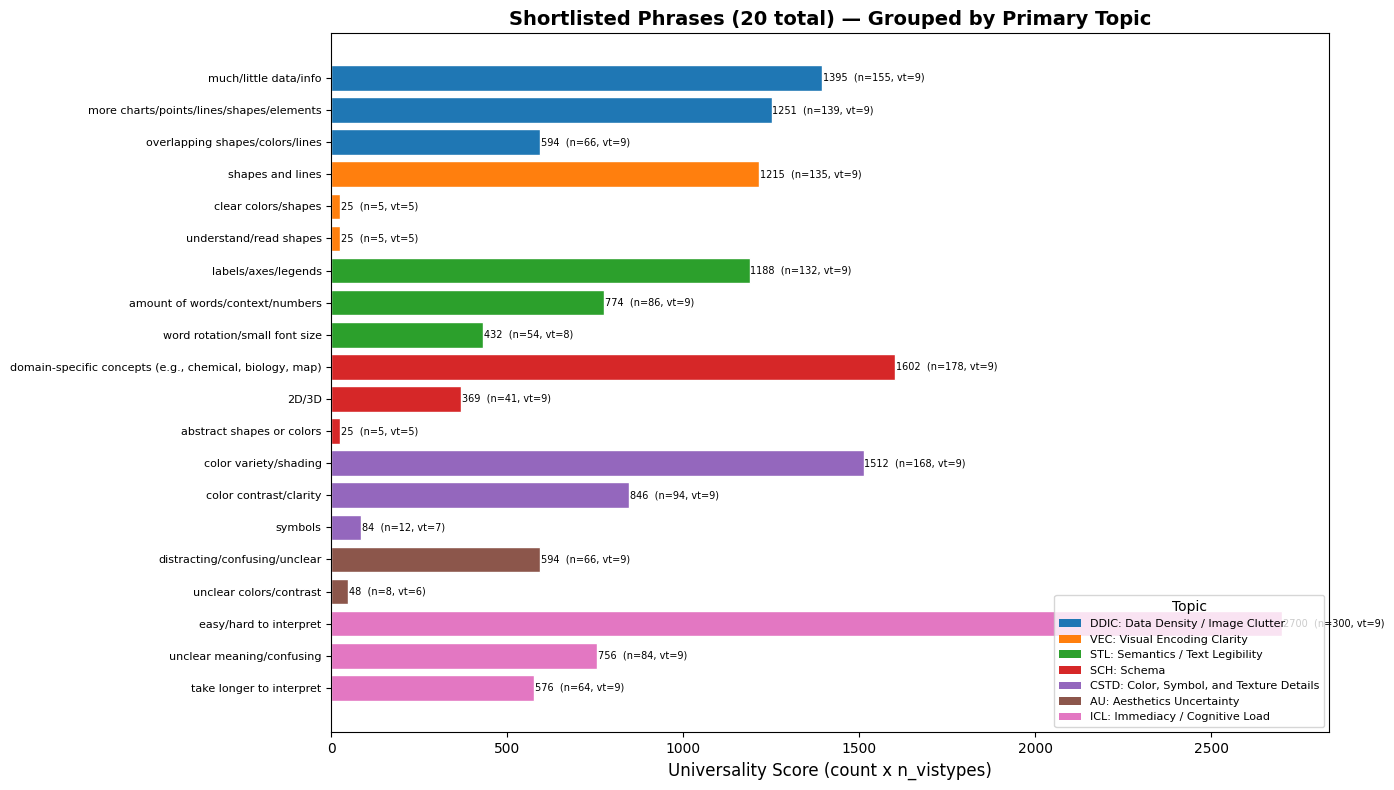

In [57]:
# ---- Step 4: Summary table and bar chart ----
print(f'SHORTLIST SUMMARY: {len(df_shortlist)} phrases\n')

# Summary table
summary_rows = []
for topic in topic_names:
    abbrev = topic_abbrev[topic]
    topic_df = df_shortlist[df_shortlist['primary_topic'] == topic]
    summary_rows.append({
        'Topic': topic,
        'Abbrev': abbrev,
        'Phrases': len(topic_df),
        'Total Count': topic_df['count'].sum(),
        'Avg Score': topic_df['universality_score'].mean() if len(topic_df) > 0 else 0
    })
df_summary = pd.DataFrame(summary_rows)
print(df_summary.to_string(index=False))

# Verify Schema has coverage
sch_count = len(df_shortlist[df_shortlist['primary_topic'] == 'Schema'])
print(f'\nSchema (SCH) phrases: {sch_count} (target >= {MIN_PER_TOPIC})')

# ---- Bar chart (grouped by topic, sorted by score within each topic) ----
from matplotlib.patches import Patch

# Sort: group by topic (in topic_names order), then by score descending within each group
topic_order = {t: i for i, t in enumerate(topic_names)}
df_chart = df_shortlist.copy()
df_chart['_topic_order'] = df_chart['primary_topic'].map(topic_order)
df_chart = df_chart.sort_values(['_topic_order', 'universality_score'], ascending=[True, False]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, max(8, len(df_chart) * 0.32)))

colors = [topic_colors.get(t, 'gray') for t in df_chart['primary_topic']]
bars = ax.barh(range(len(df_chart)), df_chart['universality_score'],
               color=colors, edgecolor='white')
ax.set_yticks(range(len(df_chart)))
ax.set_yticklabels(df_chart['keyword'], fontsize=8)
ax.invert_yaxis()
ax.set_xlabel('Universality Score (count x n_vistypes)', fontsize=12)
ax.set_title(f'Shortlisted Phrases ({len(df_chart)} total) — Grouped by Primary Topic',
             fontsize=14, fontweight='bold')

for i, (val, kw) in enumerate(zip(df_chart['universality_score'], df_chart['keyword'])):
    row = df_chart.iloc[i]
    ax.text(val + 2, i, f'{val}  (n={row["count"]}, vt={row["n_vistypes"]})',
            va='center', fontsize=7)

legend_elements = [Patch(facecolor=topic_colors[t], label=f'{topic_abbrev[t]}: {t}')
                   for t in topic_names]
ax.legend(handles=legend_elements, loc='lower right', fontsize=8, title='Topic')

plt.tight_layout()
chart_path = os.path.join(out_dir, 'phrase_shortlist_bar_chart.png')
fig.savefig(chart_path, dpi=150, bbox_inches='tight')
print(f'\nSaved chart to: {chart_path}')
plt.show()

## Step 5: Save Final Shortlist and Reduction Tracking Table

Save the shortlist and a full tracking table showing what happened to every phrase at each step.

In [58]:
# ---- Save shortlist ----
save_cols = ['keyword', 'count', 'n_vistypes', 'universality_score',
             'primary_topic', 'secondary_topic', 'vistypes_involved', 'topics_involved']
csv_path = os.path.join(out_dir, 'phrase_shortlist.csv')
df_shortlist[save_cols].to_csv(csv_path, index=False)
print(f'Saved shortlist ({len(df_shortlist)} phrases) to: {csv_path}')

# ---- Display final shortlist ----
print(f'\n{"=" * 80}')
print(f'FINAL SHORTLIST: {len(df_shortlist)} candidate phrases')
print(f'{"=" * 80}\n')
df_shortlist[save_cols]

Saved shortlist (20 phrases) to: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_shortlist.csv

FINAL SHORTLIST: 20 candidate phrases



,keyword,count,n_vistypes,universality_score,primary_topic,secondary_topic,vistypes_involved,topics_involved
0,easy/hard to interpret,300,9,2700,Immediacy / Cognitive Load,Aesthetics Uncertainty,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...","Aesthetics Uncertainty | Color, Symbol, and Te..."
1,"domain-specific concepts (e.g., chemical, biol...",178,9,1602,Schema,Aesthetics Uncertainty,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...","Aesthetics Uncertainty | Color, Symbol, and Te..."
2,color variety/shading,168,9,1512,"Color, Symbol, and Texture Details",Semantics / Text Legibility,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...","Color, Symbol, and Texture Details | Semantics..."
3,much/little data/info,155,9,1395,Data Density / Image Clutter,Visual Encoding Clarity,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",Data Density / Image Clutter | Visual Encoding...
4,more charts/points/lines/shapes/elements,139,9,1251,Data Density / Image Clutter,"Color, Symbol, and Texture Details","Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...","Color, Symbol, and Texture Details | Data Dens..."
5,shapes and lines,135,9,1215,Visual Encoding Clarity,"Color, Symbol, and Texture Details","Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...","Color, Symbol, and Texture Details | Data Dens..."
6,labels/axes/legends,132,9,1188,Semantics / Text Legibility,Visual Encoding Clarity,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",Semantics / Text Legibility | Visual Encoding ...
7,color contrast/clarity,94,9,846,"Color, Symbol, and Texture Details",Visual Encoding Clarity,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...","Color, Symbol, and Texture Details | Visual En..."
8,amount of words/context/numbers,86,9,774,Semantics / Text Legibility,Data Density / Image Clutter,"Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...",Data Density / Image Clutter | Semantics / Tex...
9,unclear meaning/confusing,84,9,756,Immediacy / Cognitive Load,"Color, Symbol, and Texture Details","Area,Bar,Cont.-ColorPatn,Glyph,Grid,Line,Node-...","Color, Symbol, and Texture Details | Immediacy..."


In [2]:
# ---- Build reduction tracking table ----
step1_kws = set(df_step1['keyword'])
step1b_kws = set(df_step1b['keyword'])
shortlist_kws = set(df_shortlist['keyword'])

tracking_rows = []
for _, row in df_all.iterrows():
    kw = row['keyword']
    count = row['count']
    n_vt = row['n_vistypes']
    topics = row['topics_involved']

    if kw in merge_map:
        rep = merge_map[kw]
        source = 'manual group' if kw in manual_merge_map else 'TF-IDF'
        sim_info = ''
        if kw in tfidf_merge_map:
            sim_info = f' (sim={tfidf_merge_map[kw][1]:.3f})'
        tracking_rows.append({
            'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
            'step1_merge': f'MERGED ({source}){sim_info}',
            'step1b_criteria': '-', 'step3_shortlist': '-',
            'removed_at': f'Step 1: merged into "{rep}"',
            'final_status': 'merged',
            'merged_into': rep
        })
        continue

    if kw not in step1b_kws:
        reason = []
        if kw in exclude_crit34:
            reason.append('Crit3/4: data artifact')
        if kw in exclude_crit5:
            reason.append('Crit5: non-visual')
        if kw in exclude_crit6:
            reason.append('Crit6: antonym lower-count')
        reason_str = '; '.join(reason) if reason else 'criterion filter'
        tracking_rows.append({
            'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
            'step1_merge': 'kept (rep)',
            'step1b_criteria': 'REMOVED', 'step3_shortlist': '-',
            'removed_at': f'Step 1b: {reason_str}',
            'final_status': 'removed',
            'merged_into': ''
        })
        continue

    if kw not in shortlist_kws:
        tracking_rows.append({
            'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
            'step1_merge': 'kept (rep)',
            'step1b_criteria': 'kept', 'step3_shortlist': 'NOT SELECTED',
            'removed_at': 'Step 3: below score threshold',
            'final_status': 'not selected',
            'merged_into': ''
        })
        continue

    tracking_rows.append({
        'keyword': kw, 'count': count, 'n_vistypes': n_vt, 'topics_involved': topics,
        'step1_merge': 'kept (rep)',
        'step1b_criteria': 'kept', 'step3_shortlist': 'SELECTED',
        'removed_at': '',
        'final_status': 'FINAL',
        'merged_into': ''
    })

df_tracking = pd.DataFrame(tracking_rows)
df_tracking = df_tracking.sort_values(['final_status', 'count'], ascending=[True, False]).reset_index(drop=True)

tracking_path = os.path.join(out_dir, 'phrase_reduction_tracking.csv')
df_tracking.to_csv(tracking_path, index=False)

# Summary
print('PHRASE REDUCTION TRACKING TABLE')
print('=' * 70)
status_counts = df_tracking['final_status'].value_counts()
for status in ['FINAL', 'merged', 'not selected', 'removed', 'discarded']:
    n = status_counts.get(status, 0)
    print(f'  {status:<20s}: {n:>4d}')
print(f'  {"TOTAL":<20s}: {len(df_tracking):>4d}')
print(f'\nSaved to: {tracking_path}')

NameError: name 'df_step1' is not defined

In [62]:
# ---- Pipeline summary ----
print('=' * 70)
print('PHRASE REDUCTION PIPELINE SUMMARY (v2 — Adaptive)')
print('=' * 70)
n_manual_merged = sum(1 for kw in merge_map if kw in manual_merge_map)
n_tfidf_merged = len(tfidf_merge_map)
n_force_merged = len(tfidf_force_merged)
print(f'  Step 0  — Raw unique phrases:              {len(df_all):>4d}')
print(f'  Step 1  — After merge-first consolidation:  {len(df_step1):>4d}')
print(f'            (manual-group merged: {n_manual_merged}, TF-IDF merged: {n_tfidf_merged}, force-merged: {n_force_merged})')
print(f'  Step 1b — After criterion filtering:        {len(df_step1b):>4d}  (-{len(df_step1) - len(df_step1b)})')
print(f'  Step 2  — Scored by universality:           {len(df_step2):>4d}  (same, just scored)')
print(f'  Step 3  — Adaptive shortlist:               {len(df_shortlist):>4d}  (MIN_PER_TOPIC={MIN_PER_TOPIC})')
print(f'\n  Overall reduction: {len(df_all)} -> {len(df_shortlist)} ({len(df_shortlist)/len(df_all)*100:.1f}% retained)')
print('=' * 70)
print(f'\n  Saved: {csv_path}')
print(f'  Saved: {chart_path}')
print(f'  Saved: {tracking_path}')
print(f'\nNext step: Review these {len(df_shortlist)} phrases before proceeding.')

PHRASE REDUCTION PIPELINE SUMMARY (v2 — Adaptive)
  Step 0  — Raw unique phrases:               400
  Step 1  — After merge-first consolidation:    51
            (manual-group merged: 333, TF-IDF merged: 21, force-merged: 16)
  Step 1b — After criterion filtering:          50  (-1)
  Step 2  — Scored by universality:             50  (same, just scored)
  Step 3  — Adaptive shortlist:                 20  (MIN_PER_TOPIC=3)

  Overall reduction: 400 -> 20 (5.0% retained)

  Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_shortlist.csv
  Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_shortlist_bar_chart.png
  Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_reduction_tracking.csv

Next step: Review these 20 phrases before proceeding.


## VisType Profile: How the Shortlisted Phrases Distribute Across Visualization Types

For each shortlisted phrase (including all merged members), compute the total occurrence count per VisType.

## Per-Image Table: imageName, VisType, Topics, finalPhrases

Build a table mapping each image to its VisType, topics, and the final shortlisted phrases (after merge + reduction).


In [63]:
import json

# ====================================================================
# 3-SHEET CHAIN: curated originals → HumanCuration → final subtopics
# ====================================================================
# Sheet 1561106523  : term mapping (curated original → HumanCuration)
# Sheet 1103808983  : image pairs  (image names, VisTypes, curated original phrases per topic)
# Sheet 1160817631  : already loaded as df_keyword_counts (HumanCuration phrases by topic)
# Chain: image → curated original → HumanCuration → pipeline shortlist

# == Step 1: Load term mapping (sheet 1561106523) ==
df_term_map = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid=1561106523&format=csv'
)

# Build forward mapping:  (topic, curated_original) → HumanCuration phrase
orig_to_hc = {}
for topic in topic_names:
    col_orig = topic
    col_hc   = f'{topic} (HumanCuration)'
    if col_orig in df_term_map.columns and col_hc in df_term_map.columns:
        for _, row in df_term_map.iterrows():
            orig = row.get(col_orig)
            hc   = row.get(col_hc)
            if pd.notna(orig) and pd.notna(hc):
                orig_to_hc[(topic, str(orig).strip())] = str(hc).strip()

print(f'Step 1 — Term mapping: {len(orig_to_hc)} (topic, original) → HumanCuration entries')
del df_term_map

# == Step 2: Load image pairs (sheet 1103808983) ==
df_pairs = pd.read_csv(
    f'https://docs.google.com/spreadsheets/d/{spreadsheet_id}/export?gid=1103808983&format=csv'
)
df_pairs = df_pairs[df_pairs['ToRemove'].isna()].copy()
print(f'Step 2 — Image pairs: {len(df_pairs)} valid rows')

vt_name_map = {
    'schematic': 'Schematic', 'Schematic': 'Schematic',
    'Points': 'Point', 'Node-link and area': 'Node-link', 'Table': 'Table',
    'Point;Line': 'Point', 'Color/Pattern': 'Cont.-ColorPatn', 'GUI': 'GUI',
}

# Topic-key normalization (some JSON keys may use " - " instead of " / ")
_topic_norm = {}
for t in topic_names:
    _topic_norm[t] = t
    _topic_norm[t.replace(' / ', ' - ')] = t

def _strip_sentiment(phrase):
    """Remove (+)/(-) prefix from curated phrases."""
    p = phrase.strip()
    if p.startswith('(+)') or p.startswith('(-)'):
        p = p[3:].strip()
    return p

def _parse_curated_json(cell_value):
    """Parse {topic: [phrases]} JSON from CuratePhrases column."""
    if not isinstance(cell_value, str) or cell_value.strip() == '':
        return {}
    try:
        d = json.loads(cell_value)
        result = {}
        for topic_key, phrases in d.items():
            topic = _topic_norm.get(topic_key, topic_key)
            if isinstance(phrases, list):
                result.setdefault(topic, [])
                for p in phrases:
                    cleaned = _strip_sentiment(str(p))
                    if cleaned:
                        result[topic].append(cleaned)
        return result
    except (json.JSONDecodeError, ValueError):
        return {}

# Build per-image data from pair rows
image_data = {}   # imageName → {'VisType': str, 'curated': {topic: set(phrases)}}

for _, row in df_pairs.iterrows():
    for img_col, vt_col, cp_col in [
        ('moreComplexImageName', 'VisTypesMoreComplexImageType', 'CuratePhrasesMoreComplex'),
        ('lessComplexImageName', 'VisTypesLessComplexImageType', 'CuratePhrasesLessComplex'),
    ]:
        img = row[img_col]
        vt  = row[vt_col]
        if pd.isna(img) or pd.isna(vt):
            continue
        vt_clean = vt_name_map.get(vt, vt)

        if img not in image_data:
            image_data[img] = {'VisType': vt_clean, 'curated': defaultdict(set)}

        curated = _parse_curated_json(row.get(cp_col, ''))
        for topic, phrases in curated.items():
            for p in phrases:
                image_data[img]['curated'][topic].add(p)

all_imgs = set(image_data.keys())
print(f'Unique images from pairs: {len(all_imgs)}')
del df_pairs

# == Step 3: Build phrase-to-final mapping ==
shortlist_kws = set(df_shortlist['keyword'])
phrase_to_final = {}
# Shortlist maps to itself
for kw in shortlist_kws:
    phrase_to_final[kw] = kw
# Merged phrases map to their representative (already renamed)
for raw, rep in merge_map.items():
    if rep in shortlist_kws:
        phrase_to_final[raw] = rep
# Pre-rename names map to post-rename names (HumanCuration uses originals)
for old_name, new_name in phrase_rename_map.items():
    if new_name in shortlist_kws:
        phrase_to_final[old_name] = new_name

print(f'Phrase-to-final mapping: {len(phrase_to_final)} entries → {len(shortlist_kws)} final phrases')

# == Step 4: Chain per-image: curated original → HumanCuration → final ==
img_rows = []
topic_cols = topic_names   # reuse downstream

for img_name, data in image_data.items():
    rec = {'ImageName': img_name, 'VisType': data['VisType']}

    all_hc       = []      # ordered list of HumanCuration phrases across topics
    all_final    = set()
    matched_tops = set()

    for topic in topic_names:
        hc_for_topic = set()
        for orig_phrase in data['curated'].get(topic, set()):
            hc = orig_to_hc.get((topic, orig_phrase))
            if hc:
                hc_for_topic.add(hc)
                matched_tops.add(topic)
                if hc in phrase_to_final:
                    all_final.add(phrase_to_final[hc])
        # Per-topic column: semicolon-separated HumanCuration phrases
        rec[topic] = '; '.join(sorted(hc_for_topic)) if hc_for_topic else ''
        all_hc.extend(sorted(hc_for_topic))

    rec['_matched_topics'] = '; '.join(sorted(matched_tops))
    rec['_hc_all']         = '; '.join(dict.fromkeys(all_hc))   # dedup preserving order
    rec['_final_phrases']  = '; '.join(sorted(all_final))
    img_rows.append(rec)

df_images = pd.DataFrame(img_rows)
df_images['VisType_clean'] = df_images['VisType']
# Keep ALL VisTypes in data (including non-standard: Schematic, GUI, Table)
# Analysis cells filter to 9 standard VisTypes as needed

# df_per_image: only images with at least one matched final phrase
df_per_image = df_images[df_images['_final_phrases'] != ''][
    ['ImageName', 'VisType', '_matched_topics', '_hc_all', '_final_phrases']
].rename(columns={
    'ImageName': 'imageName',
    '_matched_topics': 'Topics',
    '_hc_all': 'humanCuratedPhrases',
    '_final_phrases': 'finalPhrases',
}).reset_index(drop=True)

print(f'\nResults (all VisTypes):')
print(f'  Total images : {len(df_images)}')
print(f'  With HC match: {(df_images["_hc_all"] != "").sum()}')
print(f'  With final   : {len(df_per_image)}')

# Per-VisType breakdown (9 standard)
print(f'\n  9 standard VisTypes:')
for vt in VisTypes:
    n_total = (df_images['VisType'] == vt).sum()
    n_match = (df_per_image['VisType'] == vt).sum()
    print(f'    {vt:18s}: {n_match:3d} / {n_total:3d}')
# Non-standard VisTypes
other_vts = sorted(set(df_images['VisType']) - set(VisTypes))
if other_vts:
    print(f'\n  Non-standard VisTypes:')
    for vt in other_vts:
        n_total = (df_images['VisType'] == vt).sum()
        n_match = (df_per_image['VisType'] == vt).sum()
        print(f'    {vt:18s}: {n_match:3d} / {n_total:3d}')

per_image_path = os.path.join(out_dir, 'image_final_phrases.csv')
df_per_image.to_csv(per_image_path, index=False)
print(f'\nSaved: {per_image_path}')
df_per_image.head(10)

Step 1 — Term mapping: 1778 (topic, original) → HumanCuration entries
Step 2 — Image pairs: 685 valid rows
Unique images from pairs: 700
Phrase-to-final mapping: 370 entries → 20 final phrases

Results (all VisTypes):
  Total images : 700
  With HC match: 525
  With final   : 520

  9 standard VisTypes:
    Area              :  66 /  85
    Bar               :  52 /  79
    Cont.-ColorPatn   :  42 /  61
    Glyph             :  64 /  80
    Grid              :  65 /  79
    Line              :  48 /  70
    Node-link         :  66 /  85
    Point             :  58 /  78
    Text              :  51 /  68

  Non-standard VisTypes:
    GUI               :   0 /   1
    Schematic         :   7 /  13
    Table             :   1 /   1

Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\image_final_phrases.csv


,imageName,VisType,Topics,humanCuratedPhrases,finalPhrases
0,vis652.png,Point,"Aesthetics Uncertainty; Color, Symbol, and Tex...",dense/cluttered layout; little data/info; more...,amount of words/context/numbers; color contras...
1,InfoVisJ.1933.13.png,Grid,Aesthetics Uncertainty; Immediacy / Cognitive ...,distracting/confusing/unclear; read/analyze ma...,distracting/confusing/unclear
2,economist_daily_chart_521.png,Line,Aesthetics Uncertainty; Immediacy / Cognitive ...,"domain-specific concepts (e.g., chemical, biol...",distracting/confusing/unclear; domain-specific...
3,visMost786.png,Area,Immediacy / Cognitive Load,easier to interpret/read/understand,easy/hard to interpret
4,InfoVisJ.647.7(2).png,Text,Aesthetics Uncertainty,looks random/messy/lack structure,distracting/confusing/unclear
5,economist_daily_chart_393.png,Point,"Aesthetics Uncertainty; Color, Symbol, and Tex...",few points/lines/shapes/elements; little data/...,color contrast/clarity; domain-specific concep...
6,VisC.29.16.png,Line,Aesthetics Uncertainty; Schema,a specific technique; distracting/confusing/un...,distracting/confusing/unclear; domain-specific...
7,SciVisJ.980.7(2).png,Glyph,Immediacy / Cognitive Load,easy to interpret/read/understand,easy/hard to interpret
8,VASTJ.1698.5(4).png,Node-link,Aesthetics Uncertainty; Data Density / Image C...,overlapping shapes/colors/lines; 2D/3D; inform...,2D/3D; distracting/confusing/unclear; domain-s...
9,VisC.295.3.png,Cont.-ColorPatn,Aesthetics Uncertainty; Immediacy / Cognitive ...,unclear colors/contrast; hard to focus/follow,easy/hard to interpret; unclear colors/contrast


In [64]:
# Images with HC phrases but no final shortlist match
_has_hc = df_images[df_images['_hc_all'] != ''].copy()
_no_final = _has_hc[_has_hc['_final_phrases'] == '']
print(f'Images with HC phrases but no final match: {len(_no_final)}')
print(f'\nExample (first 5):')
for _, r in _no_final.head(5).iterrows():
    hc_phrases = r['_hc_all']
    print(f'  {r["ImageName"]}  [{r["VisType"]}]')
    print(f'    HC phrases: {hc_phrases}')
    # Show what these HC phrases map to in pipeline
    for p in hc_phrases.split('; '):
        p = p.strip()
        if p:
            in_merge = merge_map.get(p, '(not merged)')
            in_final = phrase_to_final.get(p, '(not in shortlist)')
            print(f'      "{p}" → merge_rep={in_merge}, final={in_final}')
    print()

del _has_hc, _no_final

Images with HC phrases but no final match: 5

Example (first 5):
  InfoVisJ.541.22.png  [Schematic]
    HC phrases: simple visual elements
      "simple visual elements" → merge_rep=(not merged), final=(not in shortlist)

  VisJ.1560.4.png  [Node-link]
    HC phrases: random-like shapes
      "random-like shapes" → merge_rep=(not merged), final=(not in shortlist)

  InfoVisC.81.3.png  [Area]
    HC phrases: shape variation
      "shape variation" → merge_rep=(not merged), final=(not in shortlist)

  VisC.373.3.png  [Schematic]
    HC phrases: random-like shapes
      "random-like shapes" → merge_rep=(not merged), final=(not in shortlist)

  InfoVisJ.2271.3.png  [Text]
    HC phrases: soft/layered/overlapping colors
      "soft/layered/overlapping colors" → merge_rep=(not merged), final=(not in shortlist)



Images per VisType:
  Area              : 85
  Bar               : 79
  Cont.-ColorPatn   : 61
  Glyph             : 80
  Grid              : 79
  Line              : 70
  Node-link         : 85
  Point             : 78
  Text              : 68
  Total: 685
Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_vistype_heatmap.png


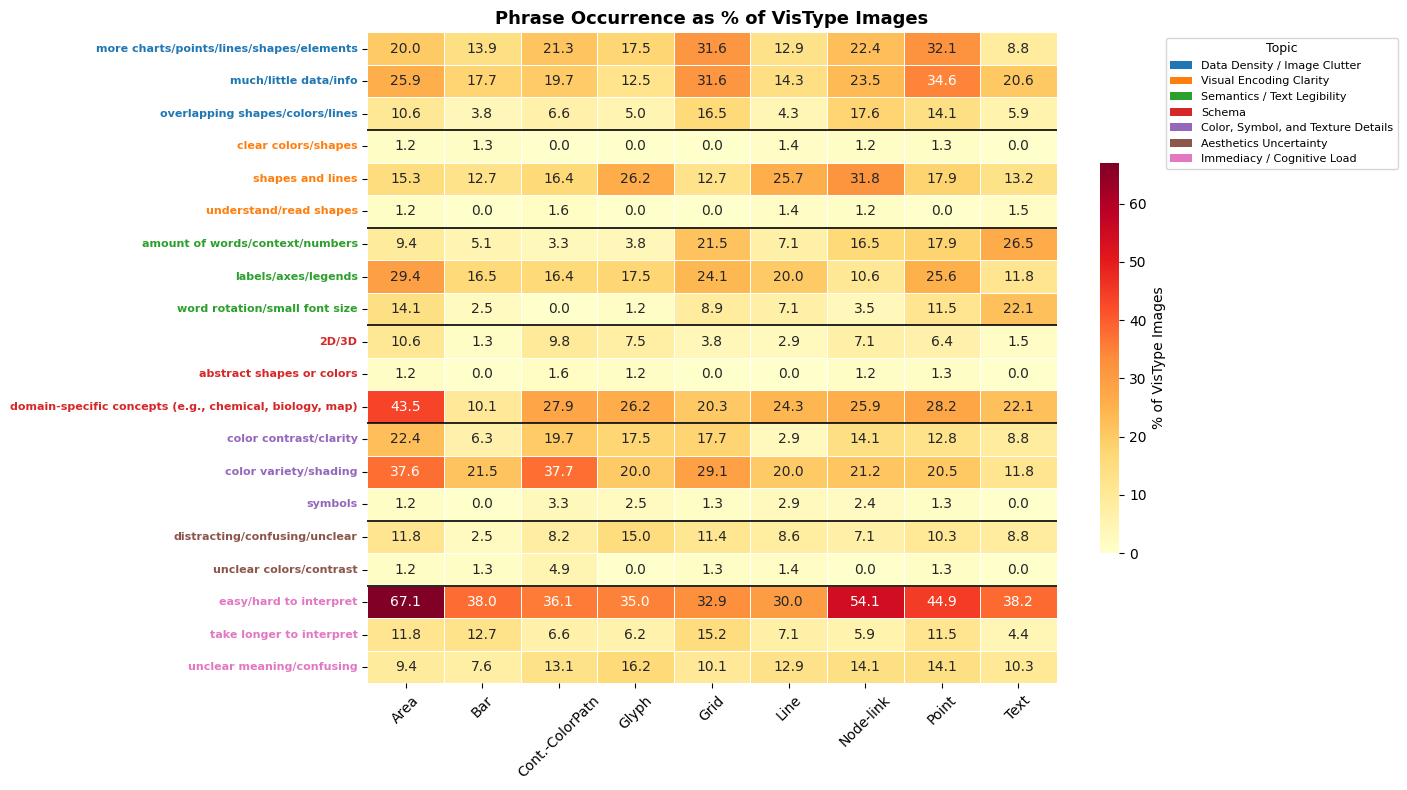

Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_vistype_stacked.png


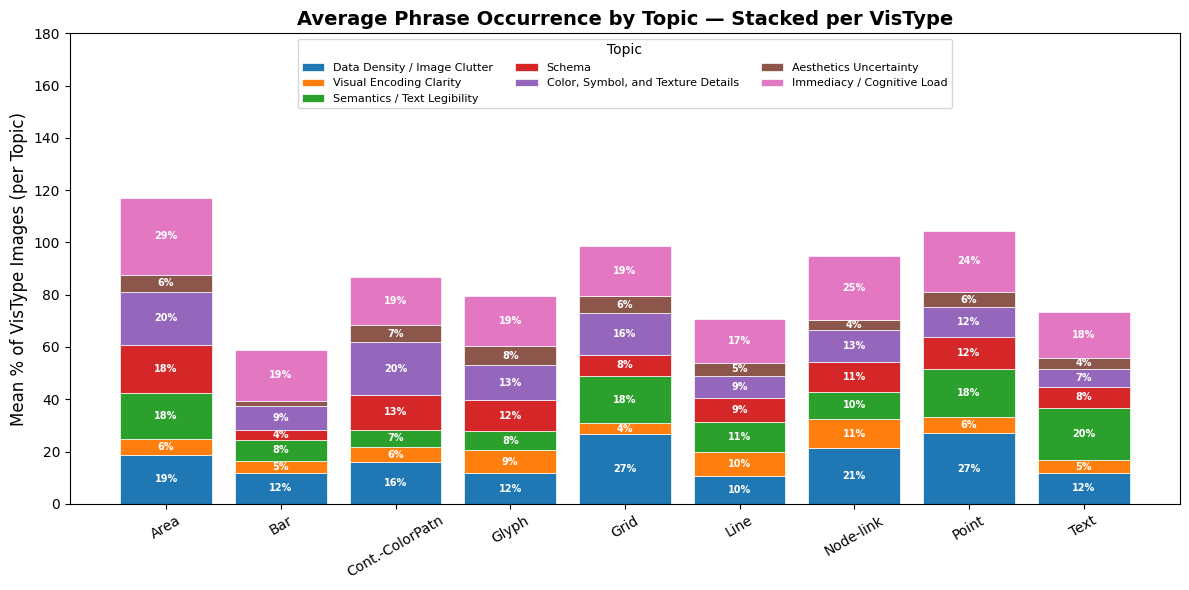

Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_vistype_radar.png


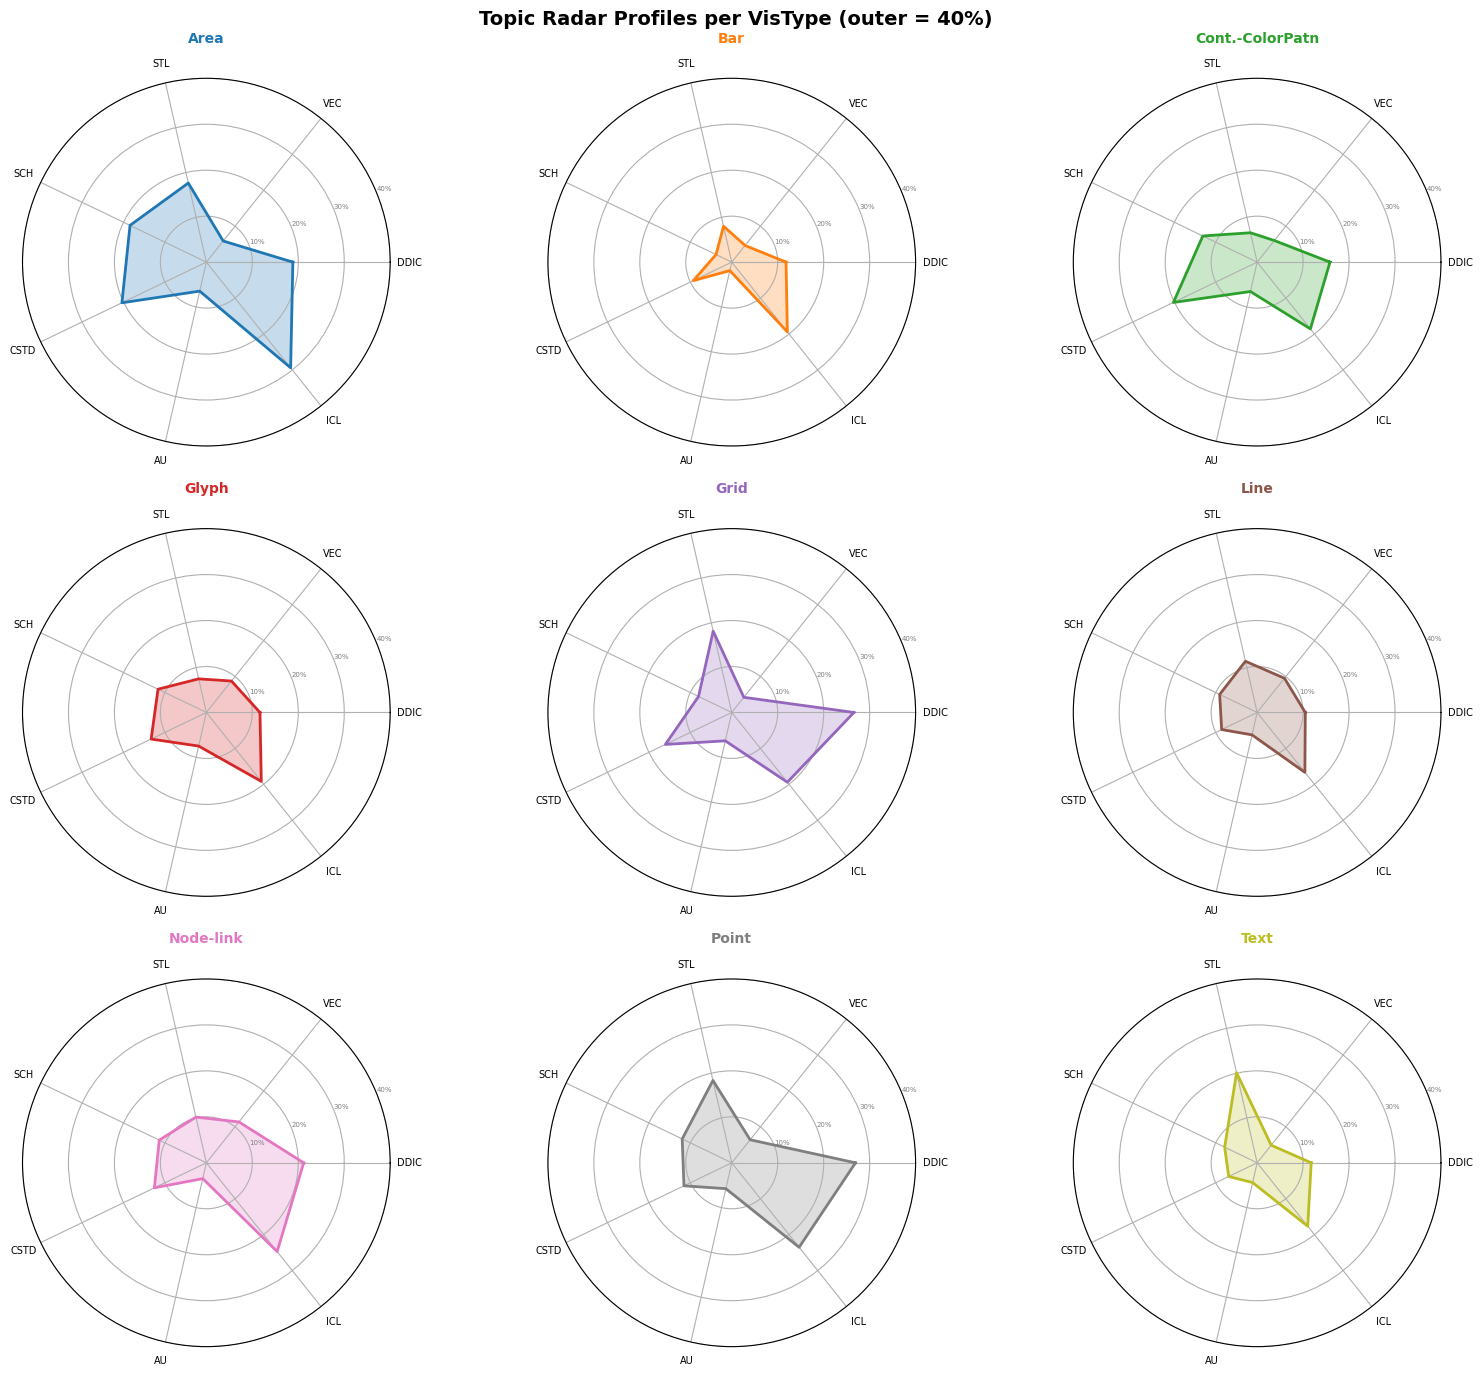


--- Normalized VisType totals (sum of % across 20 phrases) ---
  Area              :  344.7%  (out of 85 images)
  Bar               :  174.7%  (out of 79 images)
  Cont.-ColorPatn   :  254.1%  (out of 61 images)
  Glyph             :  231.2%  (out of 80 images)
  Grid              :  289.9%  (out of 79 images)
  Line              :  207.1%  (out of 70 images)
  Node-link         :  281.2%  (out of 85 images)
  Point             :  307.7%  (out of 78 images)
  Text              :  216.2%  (out of 68 images)


In [65]:
# ---- Count images per VisType for normalization (uses df_images from cell above) ----
# Count images per VisType (only the 9 we use)
vt_image_totals = {}
for vt in VisTypes:
    vt_image_totals[vt] = (df_images['VisType_clean'] == vt).sum()
print('Images per VisType:')
for vt in VisTypes:
    print(f'  {vt:18s}: {vt_image_totals[vt]}')
print(f'  Total: {sum(vt_image_totals.values())}')

# ---- Build per-VisType occurrence matrix for shortlisted phrases ----
reverse_merge = defaultdict(set)
for kw, rep in merge_map.items():
    reverse_merge[rep].add(kw)

vistype_rows = []
for _, sl_row in df_shortlist.iterrows():
    phrase = sl_row['keyword']
    member_kws = {phrase} | reverse_merge.get(phrase, set())
    member_data = df_keyword_counts[df_keyword_counts['keyword'].isin(member_kws)]
    vt_counts = {vt: member_data[vt].sum() for vt in VisTypes}
    vt_counts['keyword'] = phrase
    vt_counts['primary_topic'] = sl_row['primary_topic']
    vistype_rows.append(vt_counts)

df_vt = pd.DataFrame(vistype_rows)
df_vt['_topic_order'] = df_vt['primary_topic'].map(topic_order)
df_vt = df_vt.sort_values(['_topic_order', 'keyword']).reset_index(drop=True)

# Raw counts matrix
heat_raw = df_vt.set_index('keyword')[VisTypes]

# Normalize: % of images of that VisType mentioning each phrase
heat_norm = heat_raw.copy()
for vt in VisTypes:
    heat_norm[vt] = heat_raw[vt] / vt_image_totals[vt] * 100

# ---- Figure 1: Heatmap (normalized — % of VisType images) ----
# ---- Figure 1: Heatmap (normalized — % of VisType images) ----
from matplotlib.patches import Patch

fig, ax1 = plt.subplots(figsize=(14, max(8, len(df_vt) * 0.38)))

sns.heatmap(heat_norm, annot=True, fmt='.1f', cmap='YlOrRd', linewidths=0.5,
            cbar_kws={'label': '% of VisType Images', 'shrink': 0.6},
            ax=ax1)
ax1.set_title('Phrase Occurrence as % of VisType Images', fontsize=13, fontweight='bold')
ax1.set_ylabel('')
ax1.set_xlabel('')

# Topic separator lines
prev_topic = None
for i in range(len(df_vt)):
    cur_topic = df_vt.iloc[i]['primary_topic']
    if cur_topic != prev_topic and prev_topic is not None:
        ax1.axhline(y=i, color='black', linewidth=1.2, zorder=5)
    prev_topic = cur_topic

# Color-code y-tick labels by topic
for i, label in enumerate(ax1.get_yticklabels()):
    topic = df_vt.iloc[i]['primary_topic']
    label.set_color(topic_colors.get(topic, 'black'))
    label.set_fontweight('bold')
    label.set_fontsize(8)
ax1.tick_params(axis='x', rotation=45)

# Topic color legend
legend_patches = [Patch(facecolor=topic_colors[t], label=t) for t in topic_names]
ax1.legend(handles=legend_patches, loc='upper left', bbox_to_anchor=(1.15, 1.0),
           title='Topic', fontsize=8, title_fontsize=9, frameon=True)

plt.tight_layout()
heatmap_path = os.path.join(out_dir, 'phrase_vistype_heatmap.png')
fig.savefig(heatmap_path, dpi=150, bbox_inches='tight')
print(f'Saved: {heatmap_path}')
plt.show()

# ---- Figure 2: Stacked bar — mean % per topic per VisType ----
fig2, ax3 = plt.subplots(figsize=(12, 6))

topic_vt_means = {}
for topic in topic_names:
    topic_kws = df_vt[df_vt['primary_topic'] == topic]['keyword'].tolist()
    topic_data = heat_norm.loc[topic_kws]
    topic_vt_means[topic] = topic_data.mean()

bottom = np.zeros(len(VisTypes))
for topic in topic_names:
    vals = topic_vt_means[topic].values
    ax3.bar(VisTypes, vals, bottom=bottom, label=topic,
            color=topic_colors[topic], edgecolor='white', linewidth=0.5)
    for j, v in enumerate(vals):
        if v > 2:
            ax3.text(j, bottom[j] + v/2, f'{v:.0f}%', ha='center', va='center',
                     fontsize=7, color='white', fontweight='bold')
    bottom += vals

ax3.set_ylabel('Mean % of VisType Images (per Topic)', fontsize=12)
ax3.set_title('Average Phrase Occurrence by Topic — Stacked per VisType', fontsize=14, fontweight='bold')
ax3.legend(loc='upper center', fontsize=8, title='Topic', ncol=3)
ax3.set_ylim(0, 180)
ax3.tick_params(axis='x', rotation=30)
plt.tight_layout()
stacked_path = os.path.join(out_dir, 'phrase_vistype_stacked.png')
fig2.savefig(stacked_path, dpi=150, bbox_inches='tight')
print(f'Saved: {stacked_path}')
plt.show()

# ---- Figure 3: Radar chart — 9 VisTypes, 7 topic axes, outer = 40% ----
topic_abbrevs_short = [topic_abbrev[t] for t in topic_names]
angles = np.linspace(0, 2 * np.pi, len(topic_names), endpoint=False).tolist()
angles += angles[:1]

fig3, axes3 = plt.subplots(3, 3, figsize=(16, 14), subplot_kw=dict(polar=True))
axes3 = axes3.flatten()

# VisType colors (tab10)
vt_cmap = plt.cm.tab10
vt_colors = {vt: vt_cmap(i / len(VisTypes)) for i, vt in enumerate(VisTypes)}

for idx, vt in enumerate(VisTypes):
    ax = axes3[idx]
    # For each topic, compute mean % across phrases in that topic for this VisType
    vals = []
    for topic in topic_names:
        topic_kws = df_vt[df_vt['primary_topic'] == topic]['keyword'].tolist()
        if topic_kws:
            vals.append(heat_norm.loc[topic_kws, vt].mean())
        else:
            vals.append(0)
    vals_closed = vals + vals[:1]

    ax.fill(angles, vals_closed, alpha=0.25, color=vt_colors[vt])
    ax.plot(angles, vals_closed, color=vt_colors[vt], linewidth=2)
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(topic_abbrevs_short, fontsize=7)
    ax.set_ylim(0, 40)
    ax.set_yticks([10, 20, 30, 40])
    ax.set_yticklabels(['10%', '20%', '30%', '40%'], fontsize=5, color='gray')
    ax.set_title(vt, fontsize=10, fontweight='bold',
                 color=vt_colors[vt], pad=12)

fig3.suptitle('Topic Radar Profiles per VisType (outer = 40%)', fontsize=14, fontweight='bold')
plt.tight_layout()
radar_path = os.path.join(out_dir, 'phrase_vistype_radar.png')
fig3.savefig(radar_path, dpi=150, bbox_inches='tight')
print(f'Saved: {radar_path}')
plt.show()

# Summary: normalized totals per VisType
print(f'\n--- Normalized VisType totals (sum of % across {len(df_shortlist)} phrases) ---')
norm_totals = heat_norm.sum()
for vt in VisTypes:
    print(f'  {vt:18s}: {norm_totals[vt]:6.1f}%  (out of {vt_image_totals[vt]} images)')


Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_subtopic_radar.png


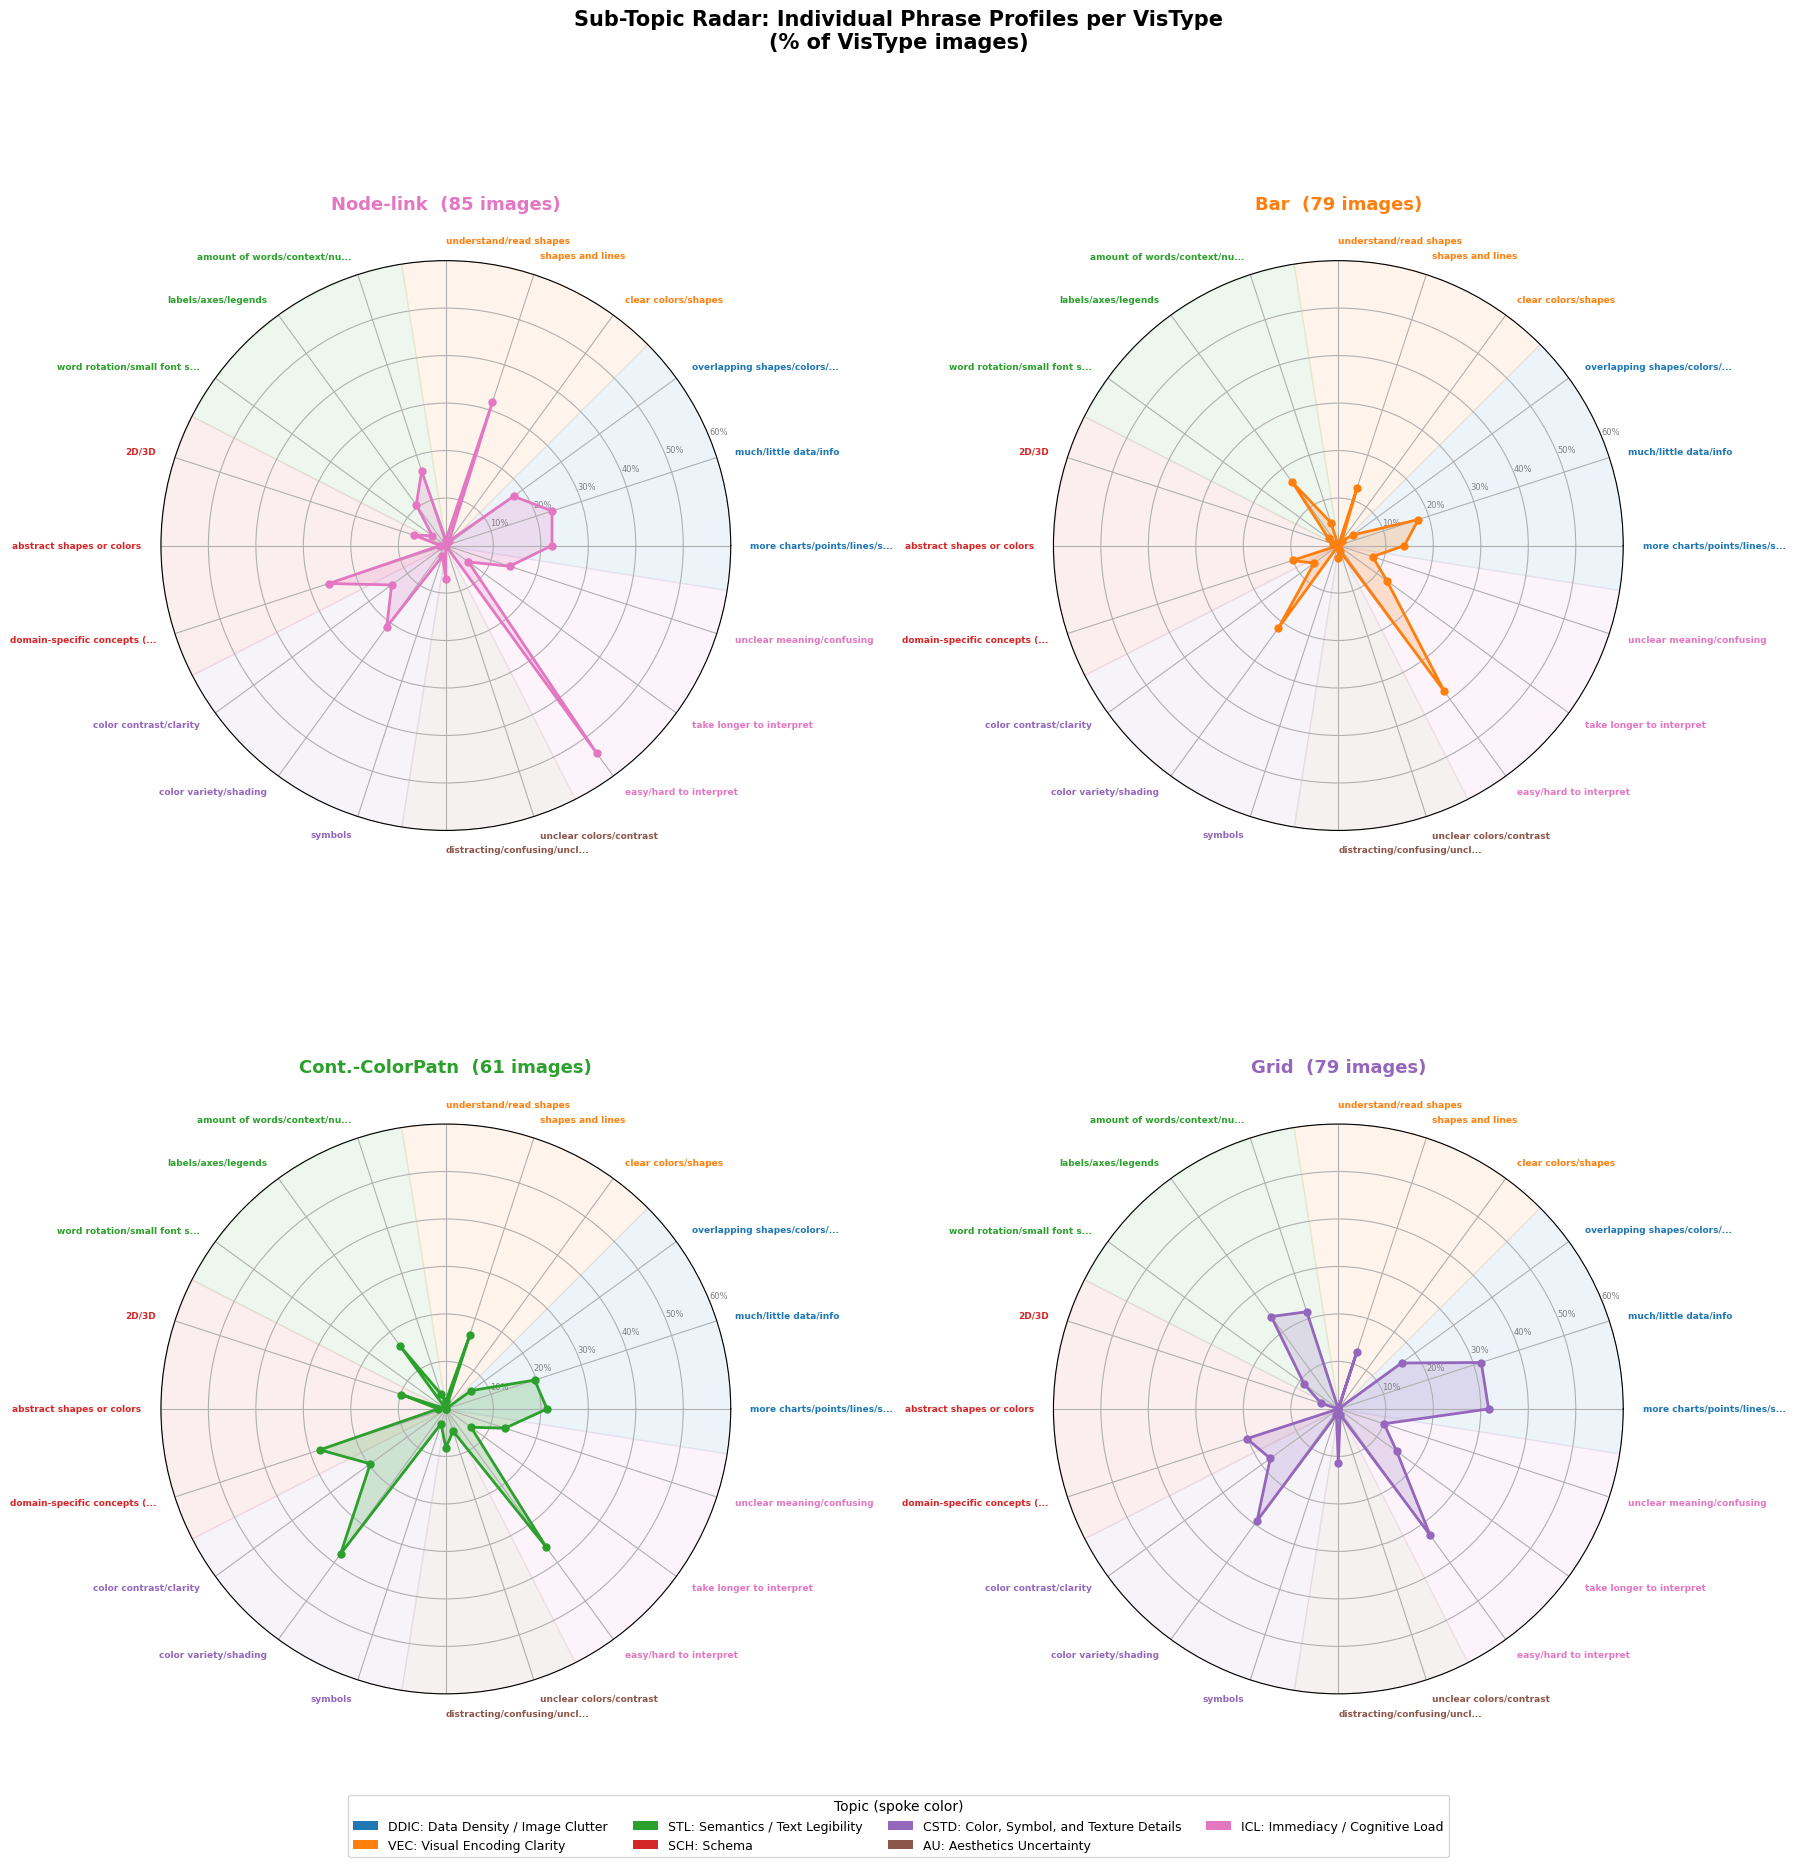


--- Node-link: Top 5 phrases by % ---
   54.1%  [ICL] easy/hard to interpret
   31.8%  [VEC] shapes and lines
   25.9%  [SCH] domain-specific concepts (e.g., chemical, biology, map)
   23.5%  [DDIC] much/little data/info
   22.4%  [DDIC] more charts/points/lines/shapes/elements

--- Bar: Top 5 phrases by % ---
   38.0%  [ICL] easy/hard to interpret
   21.5%  [CSTD] color variety/shading
   17.7%  [DDIC] much/little data/info
   16.5%  [STL] labels/axes/legends
   13.9%  [DDIC] more charts/points/lines/shapes/elements

--- Cont.-ColorPatn: Top 5 phrases by % ---
   37.7%  [CSTD] color variety/shading
   36.1%  [ICL] easy/hard to interpret
   27.9%  [SCH] domain-specific concepts (e.g., chemical, biology, map)
   21.3%  [DDIC] more charts/points/lines/shapes/elements
   19.7%  [DDIC] much/little data/info

--- Grid: Top 5 phrases by % ---
   32.9%  [ICL] easy/hard to interpret
   31.6%  [DDIC] more charts/points/lines/shapes/elements
   31.6%  [DDIC] much/little data/info
   29.1%  [CST

In [66]:
# ---- Figure 4: Sub-topic radar — individual phrase spokes for 4 VisTypes ----
from matplotlib.patches import Patch
import matplotlib.colors as mcolors

selected_vts = ['Node-link', 'Bar', 'Cont.-ColorPatn', 'Grid']

# Build ordered phrase list grouped by topic
phrase_order = []
phrase_topics = []
for topic in topic_names:
    topic_phrases = df_vt[df_vt['primary_topic'] == topic]['keyword'].tolist()
    phrase_order.extend(topic_phrases)
    phrase_topics.extend([topic] * len(topic_phrases))

n_phrases = len(phrase_order)
angles = np.linspace(0, 2 * np.pi, n_phrases, endpoint=False).tolist()
angles_closed = angles + angles[:1]

# Compute topic group boundaries (for background wedges)
topic_boundaries = []
i = 0
for topic in topic_names:
    n = len(df_vt[df_vt['primary_topic'] == topic])
    if n > 0:
        start_angle = angles[i]
        end_angle = angles[i + n - 1] if i + n - 1 < len(angles) else angles[-1]
        topic_boundaries.append((topic, i, i + n - 1, start_angle, end_angle))
        i += n

fig4, axes4 = plt.subplots(2, 2, figsize=(18, 18), subplot_kw=dict(polar=True))
axes4 = axes4.flatten()

# Determine shared radial limit across all 4 VisTypes
max_val = 0
for vt in selected_vts:
    for phrase in phrase_order:
        if phrase in heat_norm.index:
            max_val = max(max_val, heat_norm.loc[phrase, vt])
r_max = int(np.ceil(max_val / 10) * 10)
r_max = max(r_max, 40)

for idx, vt in enumerate(selected_vts):
    ax = axes4[idx]

    # Draw topic-colored background wedges
    wedge_width = 2 * np.pi / n_phrases  # angular width of one spoke
    for topic, i_start, i_end, _, _ in topic_boundaries:
        wedge_start = angles[i_start] - wedge_width / 2
        wedge_end = angles[i_end] + wedge_width / 2
        theta = np.linspace(wedge_start, wedge_end, 50)
        color = mcolors.to_rgba(topic_colors[topic], alpha=0.08)
        ax.fill_between(theta, 0, r_max, color=color, zorder=0)

    # Get values for this VisType
    vals = []
    for phrase in phrase_order:
        if phrase in heat_norm.index:
            vals.append(heat_norm.loc[phrase, vt])
        else:
            vals.append(0)
    vals_closed = vals + angles_closed[:0] + [vals[0]]  # close the polygon

    # Plot radar
    ax.fill(angles_closed, vals_closed, alpha=0.20, color=vt_colors[vt])
    ax.plot(angles_closed, vals_closed, color=vt_colors[vt], linewidth=2)

    # Plot individual dots at each spoke
    ax.scatter(angles, vals, color=vt_colors[vt], s=25, zorder=5)

    # Configure spokes
    ax.set_xticks(angles)
    # Shorten long labels for readability
    short_labels = []
    for p in phrase_order:
        if len(p) > 28:
            short_labels.append(p[:26] + '...')
        else:
            short_labels.append(p)
    ax.set_xticklabels(short_labels, fontsize=6.5)

    # Color spoke labels by topic
    for i, label in enumerate(ax.get_xticklabels()):
        topic = phrase_topics[i]
        label.set_color(topic_colors[topic])
        label.set_fontweight('bold')
        # Rotate labels for readability
        angle_deg = np.degrees(angles[i])
        if 90 < angle_deg < 270:
            label.set_ha('right')
        else:
            label.set_ha('left')

    ax.set_ylim(0, r_max)
    r_ticks = list(range(0, r_max + 1, 10))[1:]
    ax.set_yticks(r_ticks)
    ax.set_yticklabels([f'{v}%' for v in r_ticks], fontsize=6, color='gray')
    ax.set_title(f'{vt}  ({vt_image_totals[vt]} images)',
                 fontsize=13, fontweight='bold', color=vt_colors[vt], pad=20)

# Shared legend
legend_patches = [Patch(facecolor=topic_colors[t], label=f'{topic_abbrev[t]}: {t}')
                  for t in topic_names]
fig4.legend(handles=legend_patches, loc='lower center', ncol=4,
            fontsize=9, title='Topic (spoke color)', title_fontsize=10,
            bbox_to_anchor=(0.5, -0.02), frameon=True)

fig4.suptitle('Sub-Topic Radar: Individual Phrase Profiles per VisType\n(% of VisType images)',
              fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()

subtopic_radar_path = os.path.join(out_dir, 'phrase_subtopic_radar.png')
fig4.savefig(subtopic_radar_path, dpi=150, bbox_inches='tight')
print(f'Saved: {subtopic_radar_path}')
plt.show()

# Print per-VisType top phrases for quick reference
for vt in selected_vts:
    print(f'\n--- {vt}: Top 5 phrases by % ---')
    vt_vals = [(phrase, heat_norm.loc[phrase, vt]) for phrase in phrase_order if phrase in heat_norm.index]
    vt_vals.sort(key=lambda x: -x[1])
    for phrase, pct in vt_vals[:5]:
        topic = df_vt[df_vt['keyword'] == phrase]['primary_topic'].values[0]
        print(f'  {pct:5.1f}%  [{topic_abbrev[topic]}] {phrase}')

In [67]:
# ---- Export plot data to CSV ----

# 1) Heatmap data: phrase_vistype_heatmap.png
#    heat_norm indexed by keyword, columns = VisTypes, values = % of VisType images
heatmap_export = heat_norm.copy()
heatmap_export.insert(0, 'primary_topic', df_vt.set_index('keyword')['primary_topic'])
heatmap_csv_path = os.path.join(out_dir, 'phrase_vistype_heatmap_data.csv')
heatmap_export.to_csv(heatmap_csv_path)
print(f'Saved heatmap data: {heatmap_csv_path}  ({len(heatmap_export)} rows)')

# 2) Sub-topic radar data: phrase_subtopic_radar.png
#    Per-phrase % for the 4 selected VisTypes, ordered by topic
selected_vts_radar = ['Node-link', 'Bar', 'Cont.-ColorPatn', 'Grid']
radar_export = heat_norm[selected_vts_radar].copy()
radar_export.insert(0, 'primary_topic', df_vt.set_index('keyword')['primary_topic'])
radar_csv_path = os.path.join(out_dir, 'phrase_subtopic_radar_data.csv')
radar_export.to_csv(radar_csv_path)
print(f'Saved radar data: {radar_csv_path}  ({len(radar_export)} rows)')

# 3) VisType radar data: phrase_vistype_radar.png
#    Mean % per topic per VisType (7 topics × 9 VisTypes)
vistype_radar_export = pd.DataFrame(topic_vt_means).T
vistype_radar_export.index.name = 'topic'
vistype_radar_csv_path = os.path.join(out_dir, 'phrase_vistype_radar_data.csv')
vistype_radar_export.to_csv(vistype_radar_csv_path)
print(f'Saved vistype radar data: {vistype_radar_csv_path}  ({len(vistype_radar_export)} rows)')

Saved heatmap data: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_vistype_heatmap_data.csv  (20 rows)
Saved radar data: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_subtopic_radar_data.csv  (20 rows)
Saved vistype radar data: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_vistype_radar_data.csv  (7 rows)


In [68]:
# ---- Export per-VisType phrase lineage: original → humanCurated → final sub-topic ----

selected_vts_export = VisTypes  # all 9 VisTypes
shortlist_kw_set = set(df_shortlist['keyword'])

# Build full rename chain: raw phrase → human-curated representative → final name
def get_curated_and_final(raw_kw):
    """Return (humanCurated_phrase, final_phrase) for a raw keyword."""
    # Step 1: find merged representative (human-curated)
    if raw_kw in merge_map:
        curated = merge_map[raw_kw]
    elif raw_kw in phrase_rename_map:
        curated = phrase_rename_map[raw_kw]
    else:
        curated = raw_kw
    # Step 2: apply renames (some reps were renamed after merging)
    curated_display = phrase_rename_map.get(curated, curated)
    # Step 3: check if curated phrase is in the final shortlist
    final = curated_display if curated_display in shortlist_kw_set else ''
    return curated_display, final

export_rows = []
for vt in selected_vts_export:
    # Get all raw phrases that appeared in this VisType (count > 0)
    vt_data = df_keyword_counts[df_keyword_counts[vt] > 0].copy()
    for _, row in vt_data.iterrows():
        raw_kw = row['keyword']
        topic = row['topic']
        img_count = row[vt]
        curated, final = get_curated_and_final(raw_kw)
        export_rows.append({
            'VisType': vt,
            'topic': topic,
            'original_phrase': raw_kw,
            'image_count': int(img_count),
            'humanCurated_phrase': curated,
            'final_subtopic_phrase': final,
        })

df_export = pd.DataFrame(export_rows)
df_export = df_export.sort_values(['VisType', 'topic', 'final_subtopic_phrase', 'humanCurated_phrase', 'original_phrase'],
                                   ascending=[True, True, False, True, True]).reset_index(drop=True)

# Save one CSV per VisType
for vt in selected_vts_export:
    vt_df = df_export[df_export['VisType'] == vt]
    safe_name = vt.replace('.', '').replace('-', '_').replace(' ', '_')
    vt_path = os.path.join(out_dir, f'phrase_lineage_{safe_name}.csv')
    vt_df.to_csv(vt_path, index=False)
    n_orig = vt_df['original_phrase'].nunique()
    n_curated = vt_df['humanCurated_phrase'].nunique()
    n_final = vt_df[vt_df['final_subtopic_phrase'] != '']['final_subtopic_phrase'].nunique()
    print(f'{vt:18s}: {n_orig:3d} original → {n_curated:3d} humanCurated → {n_final:2d} final  | saved: {vt_path}')

# Also save a combined CSV
combined_path = os.path.join(out_dir, 'phrase_lineage_all_vistypes.csv')
df_export.to_csv(combined_path, index=False)
print(f'\nCombined CSV: {combined_path}  ({len(df_export)} rows)')

# Quick summary per VisType × topic
print(f'\n--- Final sub-topic phrases per VisType × Topic ---')
for vt in selected_vts_export:
    print(f'\n  {vt}:')
    vt_df = df_export[df_export['VisType'] == vt]
    for topic in topic_names:
        topic_df = vt_df[vt_df['topic'] == topic]
        finals = sorted(topic_df[topic_df['final_subtopic_phrase'] != '']['final_subtopic_phrase'].unique())
        if finals:
            print(f'    [{topic_abbrev[topic]:4s}] {", ".join(finals)}')

Area              : 143 original →  37 humanCurated → 20 final  | saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_lineage_Area.csv
Bar               :  82 original →  23 humanCurated → 17 final  | saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_lineage_Bar.csv
Cont.-ColorPatn   :  95 original →  24 humanCurated → 18 final  | saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_lineage_Cont_ColorPatn.csv
Glyph             : 107 original →  22 humanCurated → 17 final  | saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_lineage_Glyph.csv
Grid              : 128 original →  30 humanCurated → 17 final  | saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_lineage_Grid.csv
Line              :  84 original →  26 humanCurated → 19 final  | saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\phrase_lineage_Line.csv
Node-link         : 131 original →  

In [70]:
# ---- Ultimate: image_phrase_word_mapping.csv ----
# Only images with matched final phrases (~530 expected)

import spacy, re
from nltk.stem import SnowballStemmer

nlp = spacy.load('en_core_web_sm')
stemmer = SnowballStemmer('english')

WHITELIST_TOKENS = {'2d', '3d', '2d/3d'}

def is_valid_token(token):
    text = token.text.lower()
    if text in WHITELIST_TOKENS:
        return True
    if token.is_stop or token.is_punct or token.is_space:
        return False
    if token.pos_ == 'NUM':
        return False
    if not re.match(r'^[a-z]+(-[a-z]+)*$', text):
        return False
    if len(text) <= 1:
        return False
    return True

# Build global stem-to-word mapping from all known phrases
stem_to_word = {}
all_phrases = list(shortlist_kws) + list(merge_map.keys())
for ph in all_phrases:
    doc = nlp(ph)
    for token in doc:
        if is_valid_token(token):
            word = token.lemma_.lower()
            stem = stemmer.stem(word)
            if stem not in stem_to_word or len(word) < len(stem_to_word[stem]):
                stem_to_word[stem] = word

def extract_words(phrase_str):
    """Extract unique representative words from semicolon-separated phrases."""
    if not isinstance(phrase_str, str) or phrase_str.strip() == '':
        return ''
    phrases = [p.strip() for p in phrase_str.split(';') if p.strip()]
    stems_seen = set()
    words = []
    for ph in phrases:
        doc = nlp(ph)
        for token in doc:
            if is_valid_token(token):
                word = token.lemma_.lower()
                stem = stemmer.stem(word)
                if stem not in stems_seen:
                    stems_seen.add(stem)
                    words.append(stem_to_word.get(stem, word))
    return '; '.join(words)

# ---- Image URL base ----
IMAGE_URL_BASE = 'https://raw.githubusercontent.com/c109363/ExperimentImage/main/AllDataResize/'

# ---- Build mapping from df_per_image (only images with matched final phrases) ----
df_mapping = df_per_image.copy()
df_mapping['imageURL'] = IMAGE_URL_BASE + df_mapping['imageName']
df_mapping['words_from_humanCurated'] = df_mapping['humanCuratedPhrases'].apply(extract_words)
df_mapping['words_from_finalPhrases'] = df_mapping['finalPhrases'].apply(extract_words)

# Reorder columns
df_mapping = df_mapping[['imageName', 'imageURL', 'VisType', 'Topics',
                          'humanCuratedPhrases', 'finalPhrases',
                          'words_from_humanCurated', 'words_from_finalPhrases']]

# Save
mapping_path = os.path.join(out_dir, 'image_phrase_word_mapping.csv')
df_mapping.to_csv(mapping_path, index=False)
print(f'Saved: {mapping_path}  ({len(df_mapping)} images)')
print(f'Columns: {df_mapping.columns.tolist()}')

# Per-VisType summary
for vt in VisTypes:
    n = (df_mapping['VisType'] == vt).sum()
    if n > 0:
        print(f'  {vt:18s}: {n:3d} images')
# Non-standard VisTypes
other_vts = sorted(set(df_mapping['VisType']) - set(VisTypes))
for vt in other_vts:
    n = (df_mapping['VisType'] == vt).sum()
    if n > 0:
        print(f'  {vt:18s}: {n:3d} images (non-standard)')

df_mapping.head(5)

Saved: d:\Coding\Copilot\comment_post_processing\phrase_reduction_v2\image_phrase_word_mapping.csv  (520 images)
Columns: ['imageName', 'imageURL', 'VisType', 'Topics', 'humanCuratedPhrases', 'finalPhrases', 'words_from_humanCurated', 'words_from_finalPhrases']
  Area              :  66 images
  Bar               :  52 images
  Cont.-ColorPatn   :  42 images
  Glyph             :  64 images
  Grid              :  65 images
  Line              :  48 images
  Node-link         :  66 images
  Point             :  58 images
  Text              :  51 images
  Schematic         :   7 images (non-standard)
  Table             :   1 images (non-standard)


,imageName,imageURL,VisType,Topics,humanCuratedPhrases,finalPhrases,words_from_humanCurated,words_from_finalPhrases
0,vis652.png,https://raw.githubusercontent.com/c109363/Expe...,Point,"Aesthetics Uncertainty; Color, Symbol, and Tex...",dense/cluttered layout; little data/info; more...,amount of words/context/numbers; color contras...,dense; cluttered; layout; little; datum; info;...,word; context; number; color; contrast; clarit...
1,InfoVisJ.1933.13.png,https://raw.githubusercontent.com/c109363/Expe...,Grid,Aesthetics Uncertainty; Immediacy / Cognitive ...,distracting/confusing/unclear; read/analyze ma...,distracting/confusing/unclear,distract; confuse; unclear; read; analyze; fig...,distract; confuse; unclear
2,economist_daily_chart_521.png,https://raw.githubusercontent.com/c109363/Expe...,Line,Aesthetics Uncertainty; Immediacy / Cognitive ...,"domain-specific concepts (e.g., chemical, biol...",distracting/confusing/unclear; domain-specific...,domain; specific; concept; chemical; biology; ...,distract; confuse; unclear; domain; specific; ...
3,visMost786.png,https://raw.githubusercontent.com/c109363/Expe...,Area,Immediacy / Cognitive Load,easier to interpret/read/understand,easy/hard to interpret,easy; interpret; read; understand,easy; hard; interpret
4,InfoVisJ.647.7(2).png,https://raw.githubusercontent.com/c109363/Expe...,Text,Aesthetics Uncertainty,looks random/messy/lack structure,distracting/confusing/unclear,look; random; messy; lack; structure,distract; confuse; unclear


In [71]:
# ---- Image Funnel Summary ----
n_unique = len(image_data)
n_standard = sum(1 for v in image_data.values() if v['VisType'] in VisTypes)
n_nonstandard = n_unique - n_standard
n_with_hc = (df_images['_hc_all'] != '').sum()
n_no_hc = n_unique - n_with_hc
n_with_final = len(df_per_image)
n_hc_no_final = n_with_hc - n_with_final

std_matched = sum(1 for _, r in df_per_image.iterrows() if r['VisType'] in VisTypes)
nonstd_matched = n_with_final - std_matched

print('=' * 70)
print('IMAGE FUNNEL: from pair-comparison pool to final phrase-matched set')
print('=' * 70)
print()
print(f'  1. Unique images in pair-comparison data:       {n_unique:>4d}')
print(f'       ├─ 9 standard VisTypes:                    {n_standard:>4d}')
print(f'       └─ Non-standard (Schematic, GUI, Table):     {n_nonstandard:>2d}')
print()
print(f'  2. Images with ≥1 HumanCuration phrase:         {n_with_hc:>4d}  ({n_with_hc/n_unique*100:.1f}%)')
print(f'       └─ Images with NO curated phrases:          {n_no_hc:>3d}  ({n_no_hc/n_unique*100:.1f}%)')
print()
print(f'  3. Images with ≥1 final shortlisted phrase:     {n_with_final:>4d}  ({n_with_final/n_unique*100:.1f}%)')
print(f'       ├─ 9 standard VisTypes:                    {std_matched:>4d}')
print(f'       └─ Non-standard VisTypes:                      {nonstd_matched:>1d}')
print()
print(f'  4. Loss breakdown ({n_unique} → {n_with_final}):')
print(f'       ├─ No curated phrases at all:               {n_no_hc:>3d} images')
print(f'       └─ Had HC phrases but none in shortlist:      {n_hc_no_final:>1d} images')
print()
print(f'  Coverage: {n_with_final}/{n_unique} = {n_with_final/n_unique*100:.1f}% of all images')
print(f'            {std_matched}/{n_standard} = {std_matched/n_standard*100:.1f}% of 9-VisType images')
print('=' * 70)

IMAGE FUNNEL: from pair-comparison pool to final phrase-matched set

  1. Unique images in pair-comparison data:        700
       ├─ 9 standard VisTypes:                     685
       └─ Non-standard (Schematic, GUI, Table):     15

  2. Images with ≥1 HumanCuration phrase:          525  (75.0%)
       └─ Images with NO curated phrases:          175  (25.0%)

  3. Images with ≥1 final shortlisted phrase:      520  (74.3%)
       ├─ 9 standard VisTypes:                     512
       └─ Non-standard VisTypes:                      8

  4. Loss breakdown (700 → 520):
       ├─ No curated phrases at all:               175 images
       └─ Had HC phrases but none in shortlist:      5 images

  Coverage: 520/700 = 74.3% of all images
            512/685 = 74.7% of 9-VisType images
